# Multi-Touch Attribution (MTA/MMA): A Complete Guide
## From Theory to Implementation for Data Scientists Serving Paid Marketing Teams

---

**Author's Note:** This notebook is designed to take you from zero to expert in Multi-Touch Attribution (MTA), also commonly called Marketing Mix Attribution (MMA). It is the companion to the Marketing Mix Modeling (MMM) notebook and is written specifically for data scientists who need to support paid marketing teams with channel-level and campaign-level performance measurement.

### What You Will Learn:
1. **Foundational Theory**: What MTA is, its history, and why it matters for paid marketing
2. **Rule-Based Models**: Last-click, first-click, linear, time-decay, position-based attribution
3. **Algorithmic Models**: Markov chains, Shapley values, and logistic regression-based attribution
4. **Survival Analysis**: Time-to-conversion modeling and hazard-based attribution
5. **Incrementality & Causal Inference**: PSM, geo-lift, ghost ads, and conversion lift studies
6. **Privacy & Identity Challenges**: Cookie deprecation, iOS 14.5+, cross-device tracking
7. **Production Considerations**: Building pipelines, serving stakeholders, common pitfalls

### Prerequisites:
- Basic Python knowledge
- Familiarity with statistics (probability, regression)
- Knowledge of digital marketing concepts (helpful but not required)
- Completion of the MMM notebook (recommended but not required)

---

**Estimated Time**: 4-6 hours for complete study

---

# Section 1: Import Required Libraries

We'll use standard data science libraries plus some specialized ones for network/graph analysis (Markov chains) and causal inference.

In [1]:
# Install required packages (run once)
# !pip install pandas numpy matplotlib seaborn scipy scikit-learn networkx itertools-more lifelines

import warnings
warnings.filterwarnings('ignore')

# Core data manipulation and numerical computing
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
from collections import defaultdict, Counter
import itertools
import hashlib

# Statistical modeling
from scipy import stats
from scipy.optimize import minimize

# Machine Learning
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    roc_auc_score, precision_recall_curve, classification_report,
    confusion_matrix, average_precision_score
)
from sklearn.ensemble import GradientBoostingClassifier

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.ticker import FuncFormatter, PercentFormatter

# Set style for better visualizations
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Random seed for reproducibility
np.random.seed(42)

print("All libraries imported successfully!")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

All libraries imported successfully!
NumPy version: 2.4.1
Pandas version: 3.0.0


---

# Section 2: Understanding Multi-Touch Attribution — Theory and Foundations

## 2.1 What is Multi-Touch Attribution (MTA)?

**Multi-Touch Attribution (MTA)** is a methodology for assigning credit for a conversion (purchase, signup, lead) to the individual marketing touchpoints a user encountered along their journey. Unlike Marketing Mix Modeling (MMM), which works with **aggregate** data, MTA operates at the **user level**, tracing each person's path from first exposure to conversion.

### The Core Question MTA Answers:
> *"Which specific touchpoints in each user's journey actually drove the conversion, and how much credit does each one deserve?"*

### Key Terminology:
- **Touchpoint**: Any interaction a user has with your marketing (ad click, email open, site visit, etc.)
- **User Journey / Path**: The ordered sequence of touchpoints a user experiences before converting (or not)
- **Conversion**: The desired action (purchase, signup, app install, etc.)
- **Attribution Window**: The time period within which touchpoints are considered relevant (e.g., 30 days)
- **Lookback Window**: How far back in time you look for touchpoints before a conversion

---

## 2.2 Why MTA Matters for Paid Marketing Teams

Paid marketing teams live and die by attribution. Here's why:

### 1. **Budget Allocation Decisions**
The marketing team needs to know: *"Should I move $50K from Facebook to Google, or vice versa?"* Attribution data directly drives these decisions.

### 2. **Campaign Optimization**
Within a channel, teams optimize at the campaign, ad set, and creative level. Attribution tells them which specific ads are working.

### 3. **Performance Reporting**
Leadership asks: *"What's the ROAS on our paid search campaigns?"* Attribution provides the answer.

### 4. **Incrementality Understanding**
The hardest question: *"Would these conversions have happened anyway without this ad?"* MTA touches on this but can't fully answer it (we'll explore why).

---

## 2.3 Historical Evolution of Attribution

| Era | Approach | Characteristics |
|-----|----------|----------------|
| **Pre-2005** | Last-click only | Simple, default in all platforms |
| **2005-2012** | Rule-based multi-touch | Linear, time-decay, position-based |
| **2012-2018** | Data-driven (algorithmic) | Markov, Shapley, ML-based models |
| **2018-2021** | Unified measurement | Combining MTA + MMM + experiments |
| **2021-Present** | Privacy-first era | iOS 14.5, cookie deprecation, modeled conversions, MMM renaissance |

---

## 2.4 MTA vs. MMM — A Quick Comparison

| Dimension | MTA | MMM |
|-----------|-----|-----|
| **Data Granularity** | User-level (cookies, device IDs) | Aggregate (weekly/daily totals) |
| **Channels Covered** | Primarily digital (trackable) | All channels (TV, radio, digital, OOH) |
| **Time Horizon** | Short-term (click → conversion) | Long-term (weeks/months of carryover) |
| **Methodology** | Path analysis, ML classification | Regression, Bayesian inference |
| **Privacy Sensitivity** | HIGH (needs user-level tracking) | LOW (uses aggregate data only) |
| **Incrementality** | Cannot measure true incrementality | Can approximate with proper controls |
| **Offline Channels** | Cannot measure | Can measure |
| **Speed** | Near real-time | Quarterly/monthly refresh |
| **Best For** | Campaign-level optimization | Strategic budget allocation |

**Critical Insight**: Neither MTA nor MMM is "better" — they answer *different questions* at *different levels of granularity*. The best measurement programs use **both** plus **incrementality experiments** (triangulation).

---

## 2.5 The Fundamental Challenge: The Counterfactual Problem

The core difficulty of attribution is the **counterfactual**: *"What would have happened if this user had NOT seen this ad?"*

We can never observe both outcomes for the same user. This is the **Fundamental Problem of Causal Inference** (Holland, 1986). Every attribution model is, at best, an *approximation* of the true causal effect.

### Why This Matters Practically:
- **Correlation ≠ Causation**: A user may have seen a Facebook ad AND converted, but the ad may not have *caused* the conversion
- **Selection Bias**: Users who see more ads may already be more likely to convert (they're in-market)
- **Platform Overcounting**: Google, Meta, and other platforms all take credit for the same conversion

---

## 2.6 The Attribution Model Taxonomy

```
Attribution Models
├── Rule-Based (Heuristic)
│   ├── Single-Touch
│   │   ├── Last Click
│   │   ├── Last Non-Direct Click
│   │   └── First Click
│   └── Multi-Touch
│       ├── Linear
│       ├── Time Decay
│       └── Position-Based (U-Shaped)
│
├── Algorithmic (Data-Driven)
│   ├── Markov Chain
│   ├── Shapley Value
│   ├── Logistic Regression
│   └── Gradient Boosted Models
│
└── Causal / Experimental
    ├── Randomized Controlled Trials (A/B Tests)
    ├── Geo-Lift / Geo-Experiments
    ├── Ghost Ads / PSA Tests
    ├── Propensity Score Matching
    └── Conversion Lift Studies
```

---

# Section 3: Generating Realistic User Journey Data

We'll create a realistic simulated dataset of user journeys across multiple paid marketing channels. This lets us:
1. Know the **ground truth** (which channels actually drove conversions)
2. Test all attribution models against this ground truth
3. See how different models produce wildly different answers

### Our Simulated Business:
- **5 Paid Channels**: Paid Search, Facebook Ads, Display Ads, Email, YouTube
- **100,000 Users** over 90 days
- **Realistic conversion rates** (~3-5%)
- **Realistic journey lengths** (1-12 touchpoints)
- **Channel-specific effects**: Some channels are better at initiating, some at closing

In [2]:
def generate_user_journey_data(n_users=100000, n_days=90, seed=42):
    """
    Generate realistic user journey data with known channel effects.
    
    Ground Truth Channel Properties:
    - Paid Search: Strong closer (high conversion probability when last touch)
    - Facebook Ads: Strong initiator (great for awareness, brings users in)
    - Display Ads: Assist channel (appears in middle of journeys)
    - Email: Strong closer (high conversion when in journey)
    - YouTube: Awareness builder (long funnel, initiator role)
    
    Target CVR: ~3-5% (realistic for paid digital marketing)
    """
    np.random.seed(seed)
    
    # ============================
    # GROUND TRUTH CHANNEL EFFECTS
    # ============================
    channels = ['Paid Search', 'Facebook Ads', 'Display Ads', 'Email', 'YouTube']
    
    # Probability of each channel being the ENTRY point (awareness/initiator role)
    initiation_probs = {
        'Paid Search': 0.20,   # Some people start with search
        'Facebook Ads': 0.35,  # Strong initiator - social discovery
        'Display Ads': 0.15,   # Display for awareness
        'Email': 0.05,         # Rarely the first touch
        'YouTube': 0.25        # Video awareness
    }
    
    # Transition probabilities: given current channel, probability of next channel
    # convert/drop probabilities are tuned to produce a realistic ~3-5% overall CVR
    # (real e-commerce: 1-4%; lead gen: 2-8%)
    transition_matrix = {
        #               PS      FB      Disp    Email   YT      convert drop
        'Paid Search':  {'Paid Search': 0.20, 'Facebook Ads': 0.12, 'Display Ads': 0.22, 'Email': 0.25, 'YouTube': 0.06, 'convert': 0.04, 'drop': 0.11},
        'Facebook Ads': {'Paid Search': 0.25, 'Facebook Ads': 0.10, 'Display Ads': 0.20, 'Email': 0.10, 'YouTube': 0.10, 'convert': 0.02, 'drop': 0.23},
        'Display Ads':  {'Paid Search': 0.28, 'Facebook Ads': 0.16, 'Display Ads': 0.06, 'Email': 0.15, 'YouTube': 0.12, 'convert': 0.01, 'drop': 0.22},
        'Email':        {'Paid Search': 0.08, 'Facebook Ads': 0.04, 'Display Ads': 0.03, 'Email': 0.04, 'YouTube': 0.03, 'convert': 0.12, 'drop': 0.66},
        'YouTube':      {'Paid Search': 0.22, 'Facebook Ads': 0.22, 'Display Ads': 0.17, 'Email': 0.08, 'YouTube': 0.06, 'convert': 0.01, 'drop': 0.24},
    }
    
    # Channel average costs (CPC/CPM based)
    channel_costs = {
        'Paid Search': (1.50, 0.80),   # mean, std of cost per click
        'Facebook Ads': (0.80, 0.40),
        'Display Ads': (0.30, 0.15),
        'Email': (0.05, 0.02),
        'YouTube': (0.10, 0.05)        # CPV (cost per view)
    }
    
    # ============================
    # GENERATE USER JOURNEYS
    # ============================
    all_touchpoints = []
    journey_summaries = []
    
    start_date = datetime(2024, 1, 1)
    
    for user_id in range(n_users):
        # Determine number of touchpoints for this user (geometric distribution)
        # Most users have few touchpoints, some have many
        n_touches = min(np.random.geometric(p=0.25), 15)  # Cap at 15
        
        # Select first channel
        first_channel = np.random.choice(
            list(initiation_probs.keys()),
            p=list(initiation_probs.values())
        )
        
        journey = [first_channel]
        converted = False
        
        # Generate subsequent touchpoints using transition matrix
        current_channel = first_channel
        for touch_idx in range(1, n_touches):
            trans = transition_matrix[current_channel]
            next_states = list(trans.keys())
            next_probs = list(trans.values())
            
            next_state = np.random.choice(next_states, p=next_probs)
            
            if next_state == 'convert':
                converted = True
                break
            elif next_state == 'drop':
                break
            else:
                journey.append(next_state)
                current_channel = next_state
        
        # Generate timestamps for each touchpoint
        # Touchpoints are spread across the journey window
        journey_start_day = np.random.randint(0, n_days - 30)  # Start within first 60 days
        
        if len(journey) == 1:
            touch_days = [journey_start_day]
        else:
            # Spread touchpoints over 1-30 days
            journey_span = np.random.randint(1, min(30, n_days - journey_start_day))
            touch_days = sorted(np.random.choice(
                range(journey_start_day, journey_start_day + journey_span + 1),
                size=len(journey),
                replace=True
            ))
        
        # Store touchpoints
        for idx, (channel, day) in enumerate(zip(journey, touch_days)):
            cost_mean, cost_std = channel_costs[channel]
            cost = max(0.01, np.random.normal(cost_mean, cost_std))
            
            all_touchpoints.append({
                'user_id': user_id,
                'touchpoint_idx': idx,
                'channel': channel,
                'timestamp': start_date + timedelta(days=int(day)),
                'day': int(day),
                'cost': round(cost, 2),
                'is_first_touch': idx == 0,
                'is_last_touch': idx == len(journey) - 1,
            })
        
        # Journey summary
        journey_summaries.append({
            'user_id': user_id,
            'journey_length': len(journey),
            'journey_path': ' > '.join(journey),
            'converted': converted,
            'first_channel': journey[0],
            'last_channel': journey[-1],
            'unique_channels': len(set(journey)),
            'journey_duration_days': touch_days[-1] - touch_days[0] if len(touch_days) > 1 else 0,
        })
    
    touchpoints_df = pd.DataFrame(all_touchpoints)
    journeys_df = pd.DataFrame(journey_summaries)
    
    return touchpoints_df, journeys_df, channels

# Generate the data
touchpoints_df, journeys_df, channels = generate_user_journey_data(n_users=100000)

print("=" * 70)
print(" USER JOURNEY DATA GENERATED")
print("=" * 70)
print(f"\nTotal Users: {len(journeys_df):,}")
print(f"Total Touchpoints: {len(touchpoints_df):,}")
print(f"Conversion Rate: {journeys_df['converted'].mean():.1%}")
print(f"Total Conversions: {journeys_df['converted'].sum():,}")
print(f"\nDate Range: {touchpoints_df['timestamp'].min().strftime('%Y-%m-%d')} to {touchpoints_df['timestamp'].max().strftime('%Y-%m-%d')}")
print(f"Total Marketing Spend: ${touchpoints_df['cost'].sum():,.2f}")

print("\n" + "=" * 70)
print(" JOURNEY STATISTICS")
print("=" * 70)
print(f"\nAverage Journey Length: {journeys_df['journey_length'].mean():.1f} touchpoints")
print(f"Median Journey Length: {journeys_df['journey_length'].median():.0f} touchpoints")
print(f"Max Journey Length: {journeys_df['journey_length'].max()} touchpoints")
print(f"Average Journey Duration: {journeys_df['journey_duration_days'].mean():.1f} days")

print("\n" + "=" * 70)
print(" FIRST 5 CONVERTING JOURNEYS")
print("=" * 70)
converting = journeys_df[journeys_df['converted']].head(5)
for _, row in converting.iterrows():
    print(f"\nUser {row['user_id']}: {row['journey_path']}")
    print(f"  → {row['journey_length']} touchpoints, {row['journey_duration_days']} days")

 USER JOURNEY DATA GENERATED

Total Users: 100,000
Total Touchpoints: 214,140
Conversion Rate: 5.4%
Total Conversions: 5,376

Date Range: 2024-01-01 to 2024-03-29
Total Marketing Spend: $144,079.58

 JOURNEY STATISTICS

Average Journey Length: 2.1 touchpoints
Median Journey Length: 2 touchpoints
Max Journey Length: 15 touchpoints
Average Journey Duration: 4.1 days

 FIRST 5 CONVERTING JOURNEYS

User 6: Email
  → 1 touchpoints, 0 days

User 31: Facebook Ads > Email
  → 2 touchpoints, 1 days

User 66: Paid Search
  → 1 touchpoints, 0 days

User 107: YouTube > Facebook Ads > Facebook Ads > Display Ads > Email
  → 5 touchpoints, 5 days

User 122: YouTube > Email
  → 2 touchpoints, 0 days


---

## 3.1 Exploratory Data Analysis of User Journeys

Before building attribution models, we need to deeply understand:
1. How do journeys differ between converters and non-converters?
2. Which channels appear most at each position in the funnel?
3. What are the most common journey paths?
4. How does journey length relate to conversion probability?

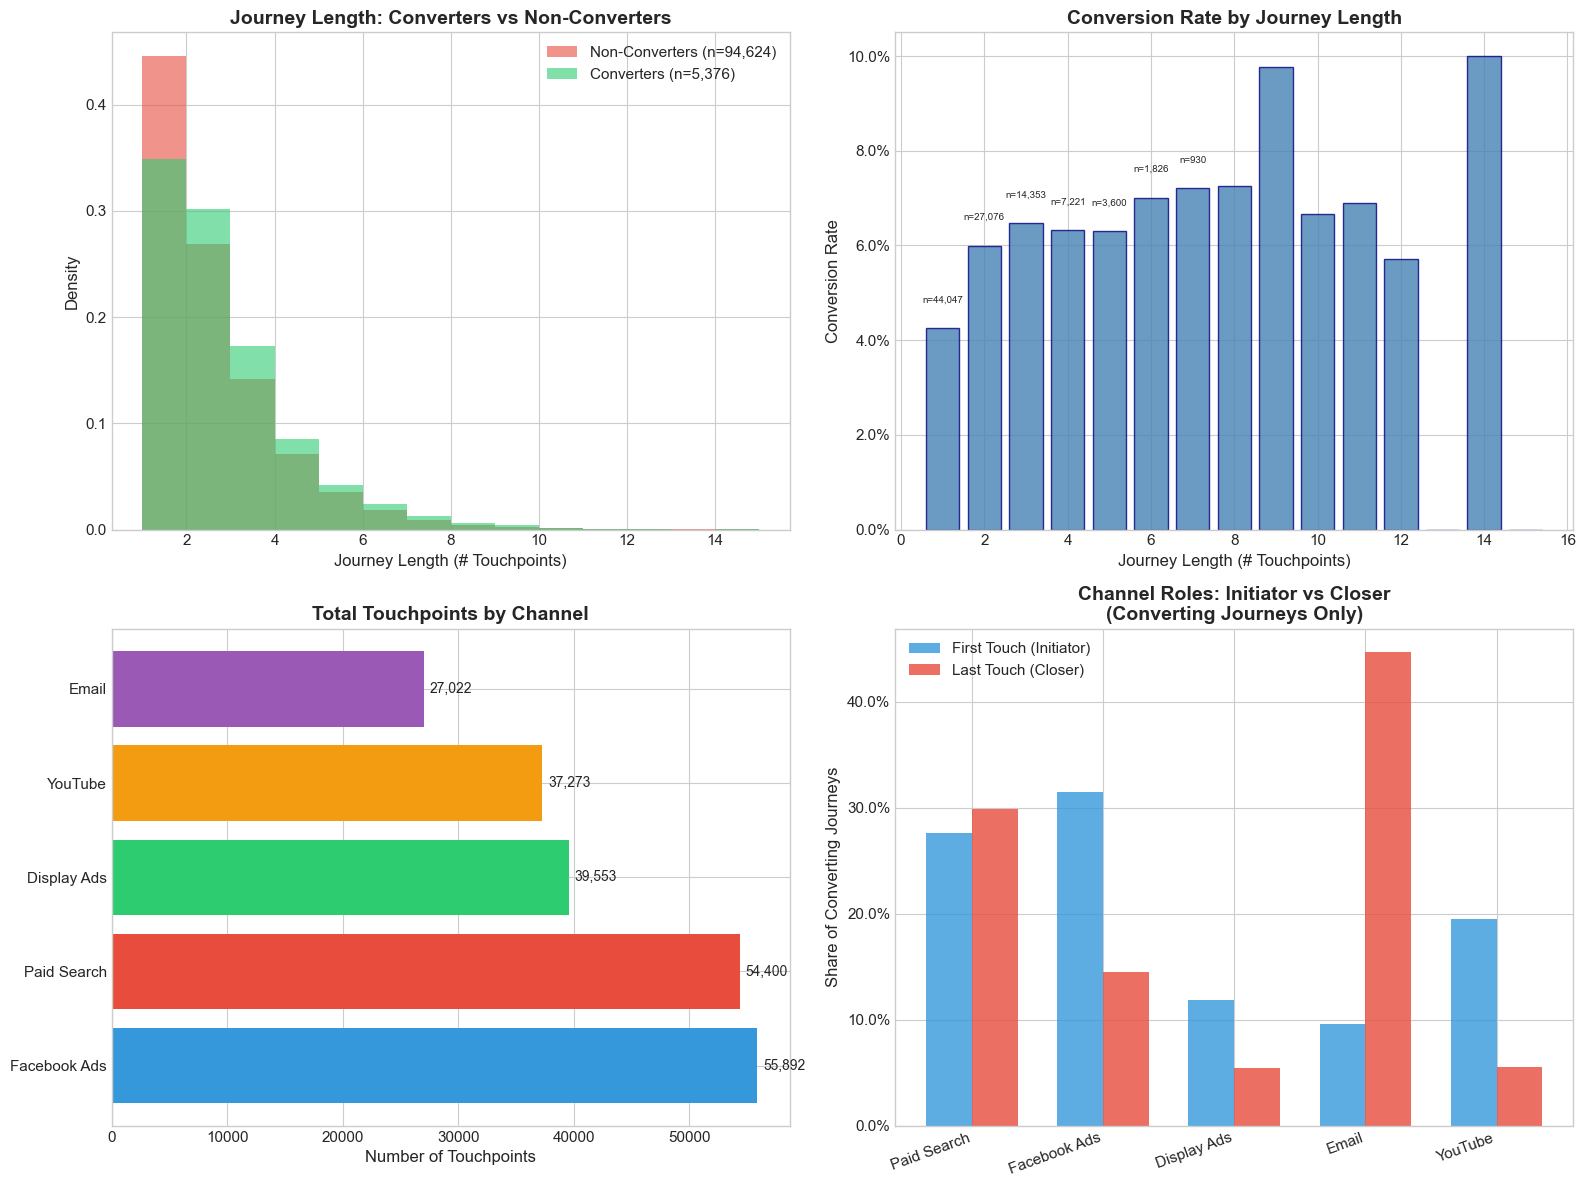


 TOP 15 MOST COMMON CONVERTING JOURNEY PATHS
   1. Paid Search                                                  (616 journeys, 11.5%)
   2. Facebook Ads                                                 (488 journeys, 9.1%)
   3. Email                                                        (461 journeys, 8.6%)
   4. Paid Search > Email                                          (316 journeys, 5.9%)
   5. Facebook Ads > Email                                         (236 journeys, 4.4%)
   6. YouTube                                                      (199 journeys, 3.7%)
   7. Facebook Ads > Paid Search                                   (176 journeys, 3.3%)
   8. Display Ads > Email                                          (144 journeys, 2.7%)
   9. YouTube > Email                                              (140 journeys, 2.6%)
  10. YouTube > Paid Search                                        (119 journeys, 2.2%)
  11. Facebook Ads > Paid Search > Email                           (112 j

In [3]:
# ============================================================================
# EDA: Understanding User Journeys
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- Plot 1: Journey Length Distribution (Converters vs Non-Converters) ---
ax1 = axes[0, 0]
converters = journeys_df[journeys_df['converted']]
non_converters = journeys_df[~journeys_df['converted']]

bins = range(1, 16)
ax1.hist(non_converters['journey_length'], bins=bins, alpha=0.6, 
         label=f'Non-Converters (n={len(non_converters):,})', density=True, color='#e74c3c')
ax1.hist(converters['journey_length'], bins=bins, alpha=0.6,
         label=f'Converters (n={len(converters):,})', density=True, color='#2ecc71')
ax1.set_xlabel('Journey Length (# Touchpoints)')
ax1.set_ylabel('Density')
ax1.set_title('Journey Length: Converters vs Non-Converters', fontweight='bold')
ax1.legend()

# --- Plot 2: Conversion Rate by Journey Length ---
ax2 = axes[0, 1]
conv_by_length = journeys_df.groupby('journey_length')['converted'].agg(['mean', 'count']).reset_index()
conv_by_length.columns = ['journey_length', 'conv_rate', 'n_users']

bars = ax2.bar(conv_by_length['journey_length'], conv_by_length['conv_rate'], 
               color='steelblue', alpha=0.8, edgecolor='navy')
ax2.set_xlabel('Journey Length (# Touchpoints)')
ax2.set_ylabel('Conversion Rate')
ax2.set_title('Conversion Rate by Journey Length', fontweight='bold')
ax2.yaxis.set_major_formatter(PercentFormatter(1.0))

# Add count labels
for bar, count in zip(bars, conv_by_length['n_users']):
    if count > 500:
        ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
                f'n={count:,}', ha='center', va='bottom', fontsize=7)

# --- Plot 3: Channel Frequency (All Touchpoints) ---
ax3 = axes[1, 0]
channel_counts = touchpoints_df['channel'].value_counts()
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']
bars = ax3.barh(channel_counts.index, channel_counts.values, color=colors)
ax3.set_xlabel('Number of Touchpoints')
ax3.set_title('Total Touchpoints by Channel', fontweight='bold')
for bar, val in zip(bars, channel_counts.values):
    ax3.text(val + 500, bar.get_y() + bar.get_height()/2., 
             f'{val:,}', va='center', fontsize=10)

# --- Plot 4: Channel Role Analysis (First vs Last Touch) ---
ax4 = axes[1, 1]

# Calculate channel appearance at each position for converters
converter_journeys = journeys_df[journeys_df['converted']]
first_touch_counts = converter_journeys['first_channel'].value_counts(normalize=True)
last_touch_counts = converter_journeys['last_channel'].value_counts(normalize=True)

x_pos = np.arange(len(channels))
width = 0.35
bars1 = ax4.bar(x_pos - width/2, [first_touch_counts.get(c, 0) for c in channels], 
                width, label='First Touch (Initiator)', color='#3498db', alpha=0.8)
bars2 = ax4.bar(x_pos + width/2, [last_touch_counts.get(c, 0) for c in channels],
                width, label='Last Touch (Closer)', color='#e74c3c', alpha=0.8)
ax4.set_xticks(x_pos)
ax4.set_xticklabels(channels, rotation=20, ha='right')
ax4.set_ylabel('Share of Converting Journeys')
ax4.set_title('Channel Roles: Initiator vs Closer\n(Converting Journeys Only)', fontweight='bold')
ax4.legend()
ax4.yaxis.set_major_formatter(PercentFormatter(1.0))

plt.tight_layout()
plt.show()

# --- Most Common Journey Paths ---
print("\n" + "=" * 70)
print(" TOP 15 MOST COMMON CONVERTING JOURNEY PATHS")
print("=" * 70)
top_paths = converter_journeys['journey_path'].value_counts().head(15)
for i, (path, count) in enumerate(top_paths.items(), 1):
    pct = count / len(converter_journeys) * 100
    print(f"  {i:2d}. {path:<60s} ({count:,} journeys, {pct:.1f}%)")

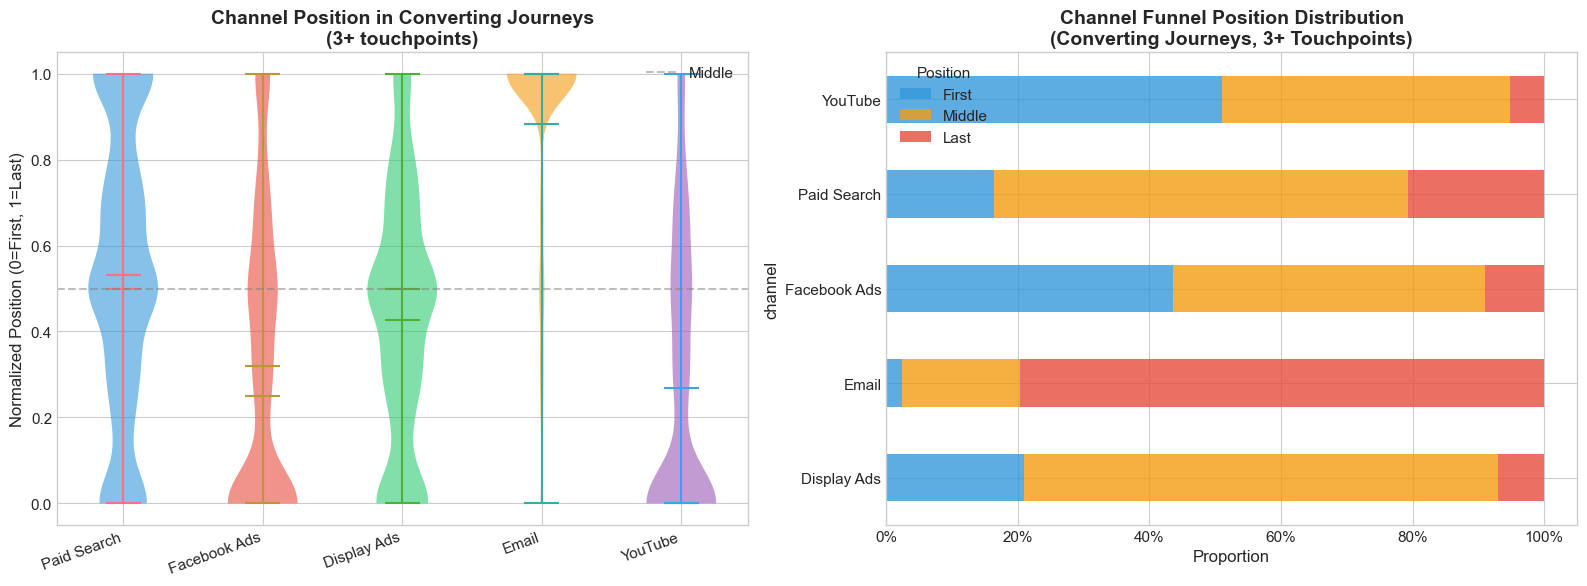


INSIGHTS:
• Facebook Ads & YouTube tend to appear early → Awareness/Initiator channels
• Paid Search & Email tend to appear late → Closer/Converter channels
• Display Ads appear throughout → Assist/Nurture channel

This is CRITICAL: different attribution models will reward different roles!


In [4]:
# ============================================================================
# Channel Position Analysis — WHERE does each channel appear in the funnel?
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# For converting journeys with 3+ touchpoints, analyze position
long_converters = converter_journeys[converter_journeys['journey_length'] >= 3]

position_data = []
for _, journey in long_converters.iterrows():
    path = journey['journey_path'].split(' > ')
    for idx, channel in enumerate(path):
        # Normalize position to 0-1 (start to end)
        norm_pos = idx / (len(path) - 1) if len(path) > 1 else 0.5
        position_data.append({
            'channel': channel,
            'position': norm_pos,
            'position_label': 'First' if idx == 0 else ('Last' if idx == len(path)-1 else 'Middle')
        })

pos_df = pd.DataFrame(position_data)

# Plot 1: Distribution of channel positions (violin plot)
ax1 = axes[0]
channel_order = channels
for i, channel in enumerate(channel_order):
    ch_data = pos_df[pos_df['channel'] == channel]['position']
    parts = ax1.violinplot([ch_data], positions=[i], showmeans=True, showmedians=True)
    for pc in parts['bodies']:
        pc.set_facecolor(colors[i])
        pc.set_alpha(0.6)

ax1.set_xticks(range(len(channel_order)))
ax1.set_xticklabels(channel_order, rotation=20, ha='right')
ax1.set_ylabel('Normalized Position (0=First, 1=Last)')
ax1.set_title('Channel Position in Converting Journeys\n(3+ touchpoints)', fontweight='bold')
ax1.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Middle')
ax1.legend()

# Plot 2: Position distribution as stacked bar
ax2 = axes[1]
pos_summary = pos_df.groupby(['channel', 'position_label']).size().unstack(fill_value=0)
pos_summary = pos_summary[['First', 'Middle', 'Last']]  # Order columns
pos_pct = pos_summary.div(pos_summary.sum(axis=1), axis=0)

pos_pct.plot(kind='barh', stacked=True, ax=ax2, 
             color=['#3498db', '#f39c12', '#e74c3c'], alpha=0.8)
ax2.set_xlabel('Proportion')
ax2.set_title('Channel Funnel Position Distribution\n(Converting Journeys, 3+ Touchpoints)', fontweight='bold')
ax2.legend(title='Position')
ax2.xaxis.set_major_formatter(PercentFormatter(1.0))

plt.tight_layout()
plt.show()

print("\nINSIGHTS:")
print("=" * 60)
print("• Facebook Ads & YouTube tend to appear early → Awareness/Initiator channels")
print("• Paid Search & Email tend to appear late → Closer/Converter channels")
print("• Display Ads appear throughout → Assist/Nurture channel")
print("\nThis is CRITICAL: different attribution models will reward different roles!")

---

# Section 4: Rule-Based Attribution Models

Rule-based models assign credit according to fixed rules. They're simple, interpretable, and still widely used — especially in platform reporting (Google Analytics, Facebook Ads Manager). However, they have significant limitations.

## 4.1 The Models We'll Implement:

| Model | Logic | Best For | Bias |
|-------|-------|----------|------|
| **Last Click** | 100% credit to last touchpoint | Direct response | Over-credits closers |
| **First Click** | 100% credit to first touchpoint | Awareness campaigns | Over-credits initiators |
| **Linear** | Equal credit to all touchpoints | Fair baseline | Ignores position importance |
| **Time Decay** | More credit to recent touchpoints | Short purchase cycles | Under-credits awareness |
| **Position-Based (U-Shaped)** | 40% first, 40% last, 20% middle | Balanced view | Arbitrary weights |

### Why Data Scientists Must Understand These:
Even if you build sophisticated algorithmic models, your **stakeholders** compare results against these heuristics. Google Analytics defaults to last-click. Facebook uses last-click within its platform. If your model says something different, you need to explain *why*.

In [5]:
# ============================================================================
# RULE-BASED ATTRIBUTION MODELS — Implementation
# ============================================================================

class RuleBasedAttribution:
    """
    Implements all standard rule-based attribution models.
    
    Each method takes a journey (list of touchpoints) and returns
    a dictionary of {channel: credit} that sums to 1.0 for each conversion.
    """
    
    @staticmethod
    def last_click(journey):
        """100% credit to the last touchpoint."""
        credits = {ch: 0.0 for ch in set(journey)}
        credits[journey[-1]] = 1.0
        return credits
    
    @staticmethod
    def first_click(journey):
        """100% credit to the first touchpoint."""
        credits = {ch: 0.0 for ch in set(journey)}
        credits[journey[0]] = 1.0
        return credits
    
    @staticmethod
    def linear(journey):
        """Equal credit to all touchpoints."""
        n = len(journey)
        credits = defaultdict(float)
        for ch in journey:
            credits[ch] += 1.0 / n
        return dict(credits)
    
    @staticmethod
    def time_decay(journey, decay_rate=0.5):
        """
        More credit to touchpoints closer to conversion.
        
        Weight formula: w_i = decay_rate^(n-1-i)
        where i is the position (0 = first) and n is journey length.
        
        Parameters:
        -----------
        decay_rate : float
            Rate at which credit decays going backward from conversion.
            0.5 means each step back gets half the credit.
            Higher = more even distribution. Lower = more concentrated on last.
        """
        n = len(journey)
        weights = [decay_rate ** (n - 1 - i) for i in range(n)]
        total_weight = sum(weights)
        
        credits = defaultdict(float)
        for ch, w in zip(journey, weights):
            credits[ch] += w / total_weight
        return dict(credits)
    
    @staticmethod
    def position_based(journey, first_weight=0.4, last_weight=0.4):
        """
        U-shaped attribution: 40% first, 40% last, 20% split among middle.
        
        Also called "bathtub" model because of the credit distribution shape.
        """
        n = len(journey)
        credits = defaultdict(float)
        
        if n == 1:
            credits[journey[0]] = 1.0
        elif n == 2:
            credits[journey[0]] += first_weight / (first_weight + last_weight)
            credits[journey[-1]] += last_weight / (first_weight + last_weight)
        else:
            middle_weight = 1.0 - first_weight - last_weight
            credits[journey[0]] += first_weight
            credits[journey[-1]] += last_weight
            n_middle = n - 2
            for ch in journey[1:-1]:
                credits[ch] += middle_weight / n_middle
        
        return dict(credits)


# ============================================================================
# APPLY ALL MODELS TO CONVERTING JOURNEYS
# ============================================================================

attribution = RuleBasedAttribution()
model_names = ['last_click', 'first_click', 'linear', 'time_decay', 'position_based']

# Store results
results = {model: defaultdict(float) for model in model_names}
total_conversions = 0

# Apply each model to every converting journey
for _, journey_row in journeys_df[journeys_df['converted']].iterrows():
    path = journey_row['journey_path'].split(' > ')
    total_conversions += 1
    
    for model_name in model_names:
        model_func = getattr(attribution, model_name)
        credits = model_func(path)
        for channel, credit in credits.items():
            results[model_name][channel] += credit

# Convert to DataFrame
attribution_results = pd.DataFrame(results).T
attribution_results.columns.name = 'Channel'
attribution_results.index.name = 'Model'

# Ensure all channels are present
for ch in channels:
    if ch not in attribution_results.columns:
        attribution_results[ch] = 0.0

attribution_results = attribution_results[channels]  # Consistent order

print("=" * 80)
print(" RULE-BASED ATTRIBUTION RESULTS")
print(f" (Total Converting Journeys: {total_conversions:,})")
print("=" * 80)
print("\nAttributed Conversions by Channel:")
print(attribution_results.round(1).to_string())

print("\n\nAttribution Shares (%):")
shares = attribution_results.div(attribution_results.sum(axis=1), axis=0) * 100
print(shares.round(1).to_string())

 RULE-BASED ATTRIBUTION RESULTS
 (Total Converting Journeys: 5,376)

Attributed Conversions by Channel:
Channel         Paid Search  Facebook Ads  Display Ads   Email  YouTube
Model                                                                  
last_click           1604.0         782.0        293.0  2400.0    297.0
first_click          1484.0        1690.0        639.0   516.0   1047.0
linear               1683.7        1209.5        592.2  1252.3    638.3
time_decay           1691.7        1024.5        497.3  1672.4    490.0
position_based       1606.7        1224.3        522.9  1368.1    654.0


Attribution Shares (%):
Channel         Paid Search  Facebook Ads  Display Ads  Email  YouTube
Model                                                                 
last_click             29.8          14.5          5.5   44.6      5.5
first_click            27.6          31.4         11.9    9.6     19.5
linear                 31.3          22.5         11.0   23.3     11.9
time_decay 

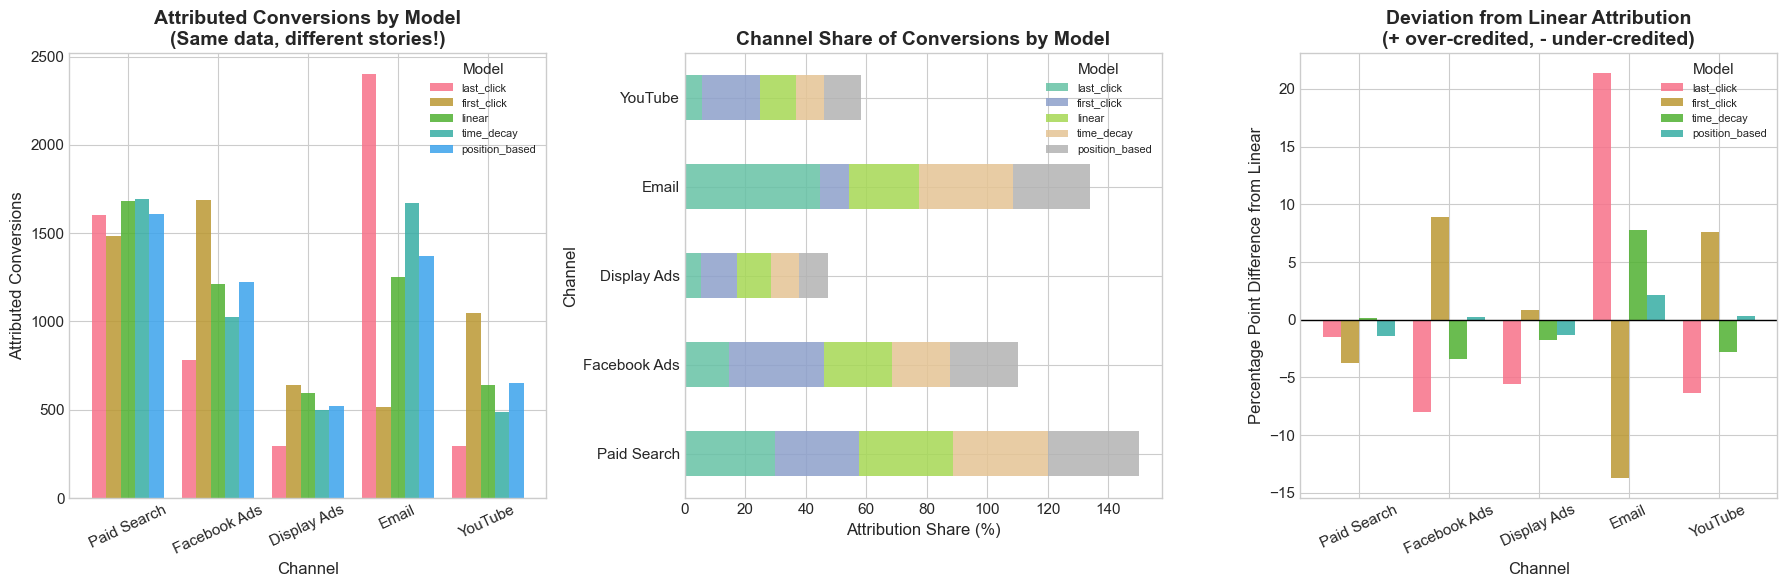


KEY INSIGHT FOR STAKEHOLDERS:

The SAME data produces completely different channel rankings depending
on which attribution model you use:

• Last-Click favors: Channels that appear at the end (Paid Search, Email)
• First-Click favors: Channels that appear at the start (Facebook, YouTube)
• Linear: Gives equal weight — a 'fair' but simplistic baseline
• Time-Decay: Similar to Last-Click but less extreme
• Position-Based: Rewards both initiators and closers

THIS is why attribution model choice is a BUSINESS decision, not just
a technical one. The model you choose changes where budget flows.



In [6]:
# ============================================================================
# VISUALIZE: How Different Models Tell DIFFERENT Stories
# ============================================================================
# This is one of the most important charts for stakeholder communication

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# --- Plot 1: Absolute attributed conversions ---
ax1 = axes[0]
attribution_results.T.plot(kind='bar', ax=ax1, width=0.8, alpha=0.85)
ax1.set_xlabel('Channel')
ax1.set_ylabel('Attributed Conversions')
ax1.set_title('Attributed Conversions by Model\n(Same data, different stories!)', fontweight='bold')
ax1.legend(title='Model', fontsize=8, bbox_to_anchor=(1.0, 1.0))
ax1.tick_params(axis='x', rotation=25)

# --- Plot 2: Attribution shares as stacked bar ---
ax2 = axes[1]
shares_t = shares.T
shares_t.plot(kind='barh', stacked=True, ax=ax2, alpha=0.85,
              color=plt.cm.Set2(np.linspace(0, 1, len(model_names))))
ax2.set_xlabel('Attribution Share (%)')
ax2.set_title('Channel Share of Conversions by Model', fontweight='bold')
ax2.legend(title='Model', fontsize=8, bbox_to_anchor=(1.0, 1.0))

# --- Plot 3: Difference from Linear (baseline) ---
ax3 = axes[2]
linear_shares = shares.loc['linear']
diff_from_linear = shares.drop('linear').sub(linear_shares, axis=1)
diff_from_linear.T.plot(kind='bar', ax=ax3, width=0.8, alpha=0.85)
ax3.axhline(y=0, color='black', linewidth=1)
ax3.set_xlabel('Channel')
ax3.set_ylabel('Percentage Point Difference from Linear')
ax3.set_title('Deviation from Linear Attribution\n(+ over-credited, - under-credited)', fontweight='bold')
ax3.legend(title='Model', fontsize=8)
ax3.tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.show()

print("\nKEY INSIGHT FOR STAKEHOLDERS:")
print("=" * 70)
print("""
The SAME data produces completely different channel rankings depending
on which attribution model you use:

• Last-Click favors: Channels that appear at the end (Paid Search, Email)
• First-Click favors: Channels that appear at the start (Facebook, YouTube)
• Linear: Gives equal weight — a 'fair' but simplistic baseline
• Time-Decay: Similar to Last-Click but less extreme
• Position-Based: Rewards both initiators and closers

THIS is why attribution model choice is a BUSINESS decision, not just
a technical one. The model you choose changes where budget flows.
""")

---

# Section 5: Markov Chain Attribution

## 5.1 Why Markov Chains?

Rule-based models ignore the **structure** of user journeys. They don't consider that certain channel sequences are more likely to lead to conversion. Markov chain attribution models the **transition probabilities** between channels and calculates each channel's contribution based on how much removing it would reduce overall conversions.

## 5.2 The Math Behind Markov Attribution

### First-Order Markov Chain:
A Markov chain models the probability of transitioning from one state to another. In attribution:
- **States** = channels + "Conversion" + "Non-Conversion" (absorbing states)
- **Transitions** = observed movement from one channel to another

$$P(S_{t+1} = j \mid S_t = i) = p_{ij}$$

The transition matrix $\mathbf{P}$ contains these probabilities:

$$\mathbf{P} = \begin{bmatrix} p_{11} & p_{12} & \cdots & p_{1n} \\ p_{21} & p_{22} & \cdots & p_{2n} \\ \vdots & & \ddots & \vdots \\ p_{n1} & p_{n2} & \cdots & p_{nn} \end{bmatrix}$$

### Removal Effect:
The key idea is the **Removal Effect**: remove each channel from the graph and measure how many conversions are lost. The channel's attribution credit is proportional to its removal effect.

$$\text{Removal Effect}(c) = 1 - \frac{P(\text{conversion} \mid \text{without channel } c)}{P(\text{conversion} \mid \text{with all channels})}$$

### Why This is Better Than Rule-Based:
1. **Data-driven**: The model learns from actual journey data
2. **Considers journey structure**: Not just position, but sequence matters
3. **Handles assists**: Channels that enable other channels get credit
4. **Removal effect is intuitive**: "What would happen without this channel?"

In [7]:
# ============================================================================
# MARKOV CHAIN ATTRIBUTION — Full Implementation
# ============================================================================

class MarkovAttribution:
    """
    Implements first-order Markov Chain attribution with removal effect.
    
    The process:
    1. Build a transition matrix from observed journey paths
    2. Calculate overall conversion probability
    3. For each channel, remove it and recalculate conversion probability
    4. The channel's credit = proportional to its removal effect
    """
    
    def __init__(self):
        self.transition_matrix = None
        self.states = None
        self.conversion_prob = None
        self.removal_effects = None
        
    def fit(self, journeys_df):
        """
        Build transition matrix from journey data.
        
        Parameters:
        -----------
        journeys_df : DataFrame with 'journey_path' and 'converted' columns
        """
        # Count transitions
        transitions = defaultdict(lambda: defaultdict(int))
        
        for _, row in journeys_df.iterrows():
            path = row['journey_path'].split(' > ')
            converted = row['converted']
            
            # Add START → first channel
            transitions['Start'][path[0]] += 1
            
            # Add channel → channel transitions
            for i in range(len(path) - 1):
                transitions[path[i]][path[i+1]] += 1
            
            # Add last channel → Conversion/Non-Conversion
            if converted:
                transitions[path[-1]]['Conversion'] += 1
            else:
                transitions[path[-1]]['Non-Conversion'] += 1
        
        # Get all states
        all_states = set()
        for source in transitions:
            all_states.add(source)
            for target in transitions[source]:
                all_states.add(target)
        
        self.states = sorted(all_states)
        
        # Build transition probability matrix
        n_states = len(self.states)
        self.transition_matrix = pd.DataFrame(
            0.0, index=self.states, columns=self.states
        )
        
        for source in transitions:
            total = sum(transitions[source].values())
            for target, count in transitions[source].items():
                self.transition_matrix.loc[source, target] = count / total
        
        # Make absorbing states truly absorbing
        for absorbing in ['Conversion', 'Non-Conversion']:
            if absorbing in self.states:
                self.transition_matrix.loc[absorbing] = 0
                self.transition_matrix.loc[absorbing, absorbing] = 1.0
        
        # Calculate overall conversion probability
        self.conversion_prob = self._calculate_conversion_prob(self.transition_matrix)
        
        # Calculate removal effects
        self._calculate_removal_effects()
        
        return self
    
    def _calculate_conversion_prob(self, trans_matrix):
        """
        Calculate the probability of reaching 'Conversion' from 'Start'
        using absorption probabilities of the Markov chain.
        
        For an absorbing Markov chain, we need to find the absorption
        probabilities. The fundamental matrix approach:
        
        1. Separate transient (T) and absorbing (A) states
        2. Extract sub-matrix Q (transient → transient)
        3. Extract sub-matrix R (transient → absorbing)
        4. Fundamental matrix N = (I - Q)^(-1)
        5. Absorption probabilities B = N × R
        """
        transient_states = [s for s in trans_matrix.index 
                          if s not in ['Conversion', 'Non-Conversion']]
        absorbing_states = ['Conversion', 'Non-Conversion']
        
        # Check if both absorbing states exist
        absorbing_present = [s for s in absorbing_states if s in trans_matrix.index]
        
        if len(transient_states) == 0 or len(absorbing_present) == 0:
            return 0.0
        
        # Q matrix (transient → transient)
        Q = trans_matrix.loc[transient_states, transient_states].values.astype(float)
        
        # R matrix (transient → absorbing)
        R = trans_matrix.loc[transient_states, absorbing_present].values.astype(float)
        
        # Fundamental matrix N = (I - Q)^(-1)
        I = np.eye(len(transient_states))
        try:
            N = np.linalg.inv(I - Q)
        except np.linalg.LinAlgError:
            # If singular, use pseudo-inverse
            N = np.linalg.pinv(I - Q)
        
        # Absorption probability matrix B = N × R
        B = N @ R
        
        # Get conversion probability from Start state
        if 'Start' in transient_states:
            start_idx = transient_states.index('Start')
            if 'Conversion' in absorbing_present:
                conv_idx = absorbing_present.index('Conversion')
                return B[start_idx, conv_idx]
        
        return 0.0
    
    def _calculate_removal_effects(self):
        """
        Calculate the removal effect for each channel.
        
        Removal effect = 1 - (conversion prob without channel / conversion prob with all)
        """
        self.removal_effects = {}
        
        # Get marketing channels (exclude Start, Conversion, Non-Conversion)
        marketing_channels = [s for s in self.states 
                            if s not in ['Start', 'Conversion', 'Non-Conversion']]
        
        for channel in marketing_channels:
            # Create modified transition matrix without this channel
            modified_matrix = self.transition_matrix.copy()
            
            # Remove the channel: redirect all transitions TO this channel 
            # to Non-Conversion (the user drops off)
            for source in modified_matrix.index:
                if source != channel:
                    # Redirect traffic that would go to removed channel → Non-Conversion
                    flow_to_removed = modified_matrix.loc[source, channel]
                    modified_matrix.loc[source, 'Non-Conversion'] += flow_to_removed
                    modified_matrix.loc[source, channel] = 0
            
            # Zero out the removed channel's row too
            modified_matrix.loc[channel] = 0
            modified_matrix.loc[channel, 'Non-Conversion'] = 1.0
            
            # Calculate conversion probability without this channel
            conv_prob_without = self._calculate_conversion_prob(modified_matrix)
            
            # Removal effect
            if self.conversion_prob > 0:
                self.removal_effects[channel] = 1 - (conv_prob_without / self.conversion_prob)
            else:
                self.removal_effects[channel] = 0
        
        return self.removal_effects
    
    def get_attribution(self, total_conversions):
        """
        Convert removal effects into attributed conversions.
        
        Each channel's share = its removal effect / sum of all removal effects
        """
        total_effect = sum(self.removal_effects.values())
        attribution = {}
        for channel, effect in self.removal_effects.items():
            share = effect / total_effect if total_effect > 0 else 0
            attribution[channel] = share * total_conversions
        return attribution


# Fit the Markov model
print("Fitting Markov Chain Attribution Model...")
markov = MarkovAttribution()
markov.fit(journeys_df)

print(f"\nOverall Conversion Probability: {markov.conversion_prob:.4f}")
print(f"Observed Conversion Rate: {journeys_df['converted'].mean():.4f}")

print("\n" + "=" * 70)
print(" MARKOV CHAIN — REMOVAL EFFECTS")
print("=" * 70)
print("\nRemoval Effect = How much conversions would DROP if this channel disappeared\n")
for channel, effect in sorted(markov.removal_effects.items(), key=lambda x: -x[1]):
    bar = '█' * int(effect * 50)
    print(f"  {channel:<15s}: {effect:.4f} ({effect*100:.1f}%) {bar}")

# Get attributed conversions
total_conv = journeys_df['converted'].sum()
markov_attribution = markov.get_attribution(total_conv)

print("\n" + "=" * 70)
print(" MARKOV CHAIN — ATTRIBUTED CONVERSIONS")
print("=" * 70)
for channel, conv in sorted(markov_attribution.items(), key=lambda x: -x[1]):
    pct = conv / total_conv * 100
    print(f"  {channel:<15s}: {conv:,.1f} conversions ({pct:.1f}%)")

Fitting Markov Chain Attribution Model...

Overall Conversion Probability: 0.0538
Observed Conversion Rate: 0.0538

 MARKOV CHAIN — REMOVAL EFFECTS

Removal Effect = How much conversions would DROP if this channel disappeared

  Paid Search    : 0.5528 (55.3%) ███████████████████████████
  Email          : 0.4692 (46.9%) ███████████████████████
  Facebook Ads   : 0.4262 (42.6%) █████████████████████
  Display Ads    : 0.2822 (28.2%) ██████████████
  YouTube        : 0.2591 (25.9%) ████████████

 MARKOV CHAIN — ATTRIBUTED CONVERSIONS
  Paid Search    : 1,493.7 conversions (27.8%)
  Email          : 1,267.7 conversions (23.6%)
  Facebook Ads   : 1,151.8 conversions (21.4%)
  Display Ads    : 762.5 conversions (14.2%)
  YouTube        : 700.2 conversions (13.0%)


In [8]:
# ============================================================================
# STEP-BY-STEP: How We Get From Transition Matrix → Attributed Conversions
# ============================================================================
# This cell walks through the Markov math one step at a time so you can see
# exactly what's happening inside the model.

# ─────────────────────────────────────────────────────────────────────────────
# STEP 1: Counting raw transitions from journey data
# ─────────────────────────────────────────────────────────────────────────────

print("=" * 70)
print(" STEP 1: From Journey Paths → Transition Counts")
print("=" * 70)

# Show example journeys and their transitions
example_journeys = journeys_df.head(8)
print("\nTracing 8 example journeys to show how transitions are extracted:\n")

for idx, row in example_journeys.iterrows():
    path = row['journey_path'].split(' > ')
    outcome = "✓ CONVERTED" if row['converted'] else "✗ dropped"
    print(f"  User {row['user_id']}: {row['journey_path']}  [{outcome}]")
    
    transitions_list = [f"Start → {path[0]}"]
    for i in range(len(path) - 1):
        transitions_list.append(f"{path[i]} → {path[i+1]}")
    if row['converted']:
        transitions_list.append(f"{path[-1]} → Conversion")
    else:
        transitions_list.append(f"{path[-1]} → Non-Conversion")
    
    print(f"    Transitions: {' | '.join(transitions_list)}")
    print()

print("These transitions from ALL 100K journeys are counted up to build the")
print("transition matrix. Each cell = count(A→B) / count(all transitions from A).")

# ─────────────────────────────────────────────────────────────────────────────
# STEP 2: The Transition Probability Matrix
# ─────────────────────────────────────────────────────────────────────────────

print("\n" + "=" * 70)
print(" STEP 2: The Transition Probability Matrix")
print("=" * 70)

display_states = ['Start'] + channels + ['Conversion', 'Non-Conversion']
display_states = [s for s in display_states if s in markov.transition_matrix.index]
trans_display = markov.transition_matrix.loc[display_states, display_states]

print("\nEach row sums to 1.0 (from any state, you must go SOMEWHERE).")
print("Read as: 'Given I'm at [ROW], the probability of going to [COLUMN] is...'\n")

# Print formatted matrix
header = f"{'From / To':<18s}" + "".join(f"{s:>16s}" for s in display_states) + f"{'Row Sum':>10s}"
print(header)
print("─" * len(header))

for state in display_states:
    row_vals = trans_display.loc[state]
    row_str = f"{state:<18s}"
    for col_state in display_states:
        val = row_vals[col_state]
        if val < 0.001:
            row_str += f"{'·':>16s}"
        else:
            row_str += f"{val:>16.3f}"
    row_str += f"{row_vals.sum():>10.3f}"
    print(row_str)

print("\n💡 Key observations:")
print(f"   • Email has the highest direct conversion probability: "
      f"{trans_display.loc['Email', 'Conversion']:.3f}")
print(f"   • Display Ads has the lowest: "
      f"{trans_display.loc['Display Ads', 'Conversion']:.3f}")
print(f"   • Facebook Ads frequently leads to Paid Search: "
      f"{trans_display.loc['Facebook Ads', 'Paid Search']:.3f}")
print(f"   • Conversion and Non-Conversion are absorbing states (self-loop = 1.0)")

 STEP 1: From Journey Paths → Transition Counts

Tracing 8 example journeys to show how transitions are extracted:

  User 0: YouTube > YouTube  [✗ dropped]
    Transitions: Start → YouTube | YouTube → YouTube | YouTube → Non-Conversion

  User 1: Paid Search > Email  [✗ dropped]
    Transitions: Start → Paid Search | Paid Search → Email | Email → Non-Conversion

  User 2: Paid Search  [✗ dropped]
    Transitions: Start → Paid Search | Paid Search → Non-Conversion

  User 3: Facebook Ads > Display Ads  [✗ dropped]
    Transitions: Start → Facebook Ads | Facebook Ads → Display Ads | Display Ads → Non-Conversion

  User 4: Paid Search > Paid Search  [✗ dropped]
    Transitions: Start → Paid Search | Paid Search → Paid Search | Paid Search → Non-Conversion

  User 5: Facebook Ads > Paid Search > Display Ads > Paid Search  [✗ dropped]
    Transitions: Start → Facebook Ads | Facebook Ads → Paid Search | Paid Search → Display Ads | Display Ads → Paid Search | Paid Search → Non-Conversion

  


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


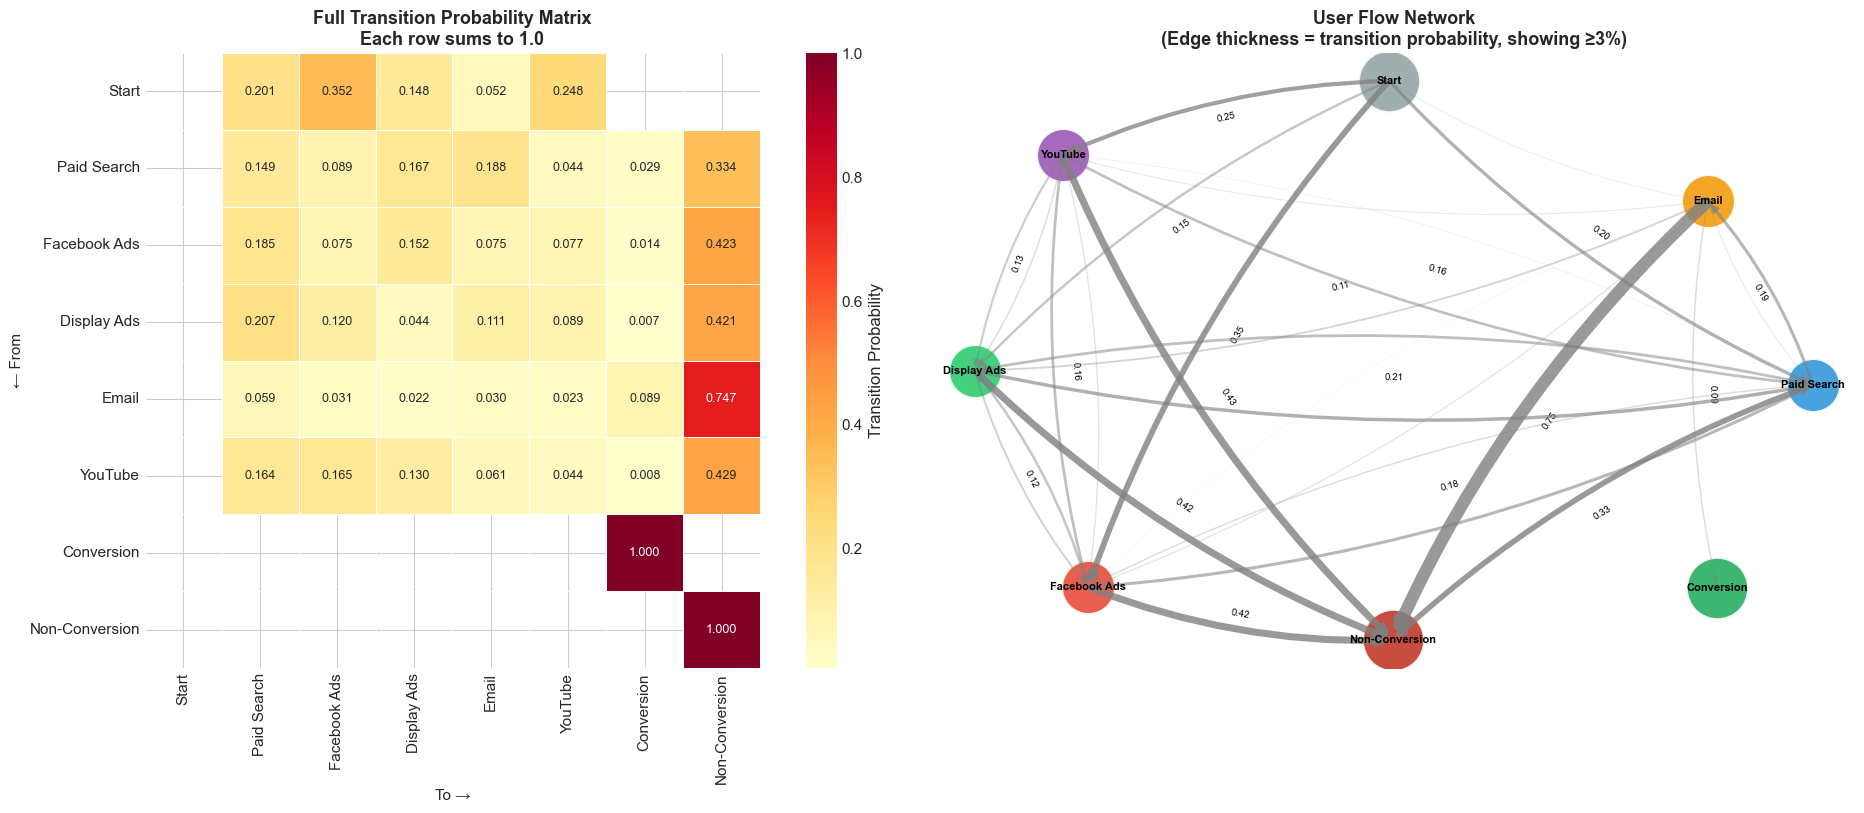


💡 Read the network: thick arrows = high-traffic paths.
   Notice how Facebook Ads often feeds INTO Paid Search (awareness → intent),
   and Email is the most direct path TO Conversion.


In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 2b: VISUALIZE the transition matrix as a network graph
# ─────────────────────────────────────────────────────────────────────────────
# This makes it much easier to see the "flow" of users through channels.

%pip install networkx --quiet
import networkx as nx

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# --- LEFT: Heatmap of transition probabilities ---
ax1 = axes[0]
display_states_viz = ['Start'] + channels + ['Conversion', 'Non-Conversion']
display_states_viz = [s for s in display_states_viz if s in markov.transition_matrix.index]
trans_viz = markov.transition_matrix.loc[display_states_viz, display_states_viz]
mask = trans_viz < 0.005

sns.heatmap(trans_viz, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax1,
            mask=mask, linewidths=0.5, square=True,
            cbar_kws={'label': 'Transition Probability'},
            annot_kws={'size': 9})
ax1.set_title('Full Transition Probability Matrix\nEach row sums to 1.0', 
              fontweight='bold', fontsize=13)
ax1.set_xlabel('To →', fontsize=11)
ax1.set_ylabel('← From', fontsize=11)

# --- RIGHT: Network diagram showing major flows ---
ax2 = axes[1]

G = nx.DiGraph()
node_colors_map = {
    'Start': '#95a5a6',
    'Paid Search': '#3498db', 'Facebook Ads': '#e74c3c', 
    'Display Ads': '#2ecc71', 'Email': '#f39c12', 'YouTube': '#9b59b6',
    'Conversion': '#27ae60', 'Non-Conversion': '#c0392b'
}

for state in display_states_viz:
    G.add_node(state)

# Add edges with weight > threshold
edge_threshold = 0.03
for source in display_states_viz:
    for target in display_states_viz:
        prob = trans_viz.loc[source, target]
        if prob > edge_threshold and source != target:
            # Skip absorbing self-loops
            if source in ['Conversion', 'Non-Conversion']:
                continue
            G.add_edge(source, target, weight=prob)

# Layout
pos = nx.spring_layout(G, k=2.5, seed=42, iterations=50)

# Draw edges with width proportional to probability
edges = G.edges(data=True)
edge_widths = [d['weight'] * 12 for _, _, d in edges]
edge_alphas = [min(d['weight'] * 3, 0.8) for _, _, d in edges]

for (u, v, d), width, alpha in zip(edges, edge_widths, edge_alphas):
    ax2.annotate("", xy=pos[v], xytext=pos[u],
                arrowprops=dict(arrowstyle="-|>", lw=width, 
                              color='gray', alpha=alpha,
                              connectionstyle="arc3,rad=0.1"))

# Draw nodes
for node in G.nodes():
    color = node_colors_map.get(node, '#bdc3c7')
    size = 2000 if node in ['Start', 'Conversion', 'Non-Conversion'] else 1500
    nx.draw_networkx_nodes(G, pos, nodelist=[node], node_color=color,
                          node_size=size, ax=ax2, alpha=0.9, edgecolors='white', linewidths=2)

# Labels
nx.draw_networkx_labels(G, pos, font_size=8, font_weight='bold', ax=ax2)

# Add edge labels for top transitions
edge_labels = {(u, v): f"{d['weight']:.2f}" for u, v, d in edges if d['weight'] > 0.08}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7, ax=ax2)

ax2.set_title('User Flow Network\n(Edge thickness = transition probability, showing ≥3%)', 
              fontweight='bold', fontsize=13)
ax2.axis('off')

plt.tight_layout()
plt.show()

print("\n💡 Read the network: thick arrows = high-traffic paths.")
print("   Notice how Facebook Ads often feeds INTO Paid Search (awareness → intent),")
print("   and Email is the most direct path TO Conversion.")

In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 3: The Absorption Math (I - Q)⁻¹ × R
# ─────────────────────────────────────────────────────────────────────────────
# This is where it gets interesting. We solve for the EXACT probability of
# converting from each state using matrix algebra on the Markov chain.

print("=" * 70)
print(" STEP 3: Absorption Probabilities via Fundamental Matrix")
print("=" * 70)

# Identify transient and absorbing states
transient_states = [s for s in markov.transition_matrix.index 
                    if s not in ['Conversion', 'Non-Conversion']]
absorbing_states = ['Conversion', 'Non-Conversion']

print(f"\nTransient states (channels + Start): {transient_states}")
print(f"Absorbing states (once you arrive, you stay): {absorbing_states}")

# Extract Q and R matrices
Q = markov.transition_matrix.loc[transient_states, transient_states].values.astype(float)
R = markov.transition_matrix.loc[transient_states, absorbing_states].values.astype(float)

print(f"\n{'─'*70}")
print("Q matrix (transient → transient transitions):")
print("This captures how users bounce BETWEEN channels.\n")
Q_df = pd.DataFrame(Q, index=transient_states, columns=transient_states)
for state in transient_states:
    row_str = f"  {state:<15s}: "
    row_str += "  ".join(f"{Q_df.loc[state, col]:>6.3f}" for col in transient_states)
    print(row_str)

print(f"\n{'─'*70}")
print("R matrix (transient → absorbing transitions):")
print("This captures the probability of converting/dropping from each state.\n")
R_df = pd.DataFrame(R, index=transient_states, columns=absorbing_states)
print(f"  {'State':<15s} {'Conversion':>12s} {'Non-Conversion':>16s}")
for state in transient_states:
    print(f"  {state:<15s} {R_df.loc[state, 'Conversion']:>12.4f} "
          f"{R_df.loc[state, 'Non-Conversion']:>16.4f}")

print(f"\n{'─'*70}")
print("Fundamental Matrix: N = (I - Q)⁻¹")
print("N[i,j] = expected number of times you visit state j before being")
print("absorbed, given you started at state i.\n")

I_mat = np.eye(len(transient_states))
N = np.linalg.inv(I_mat - Q)
N_df = pd.DataFrame(N, index=transient_states, columns=transient_states)

print(f"  {'From \\ Visit':<15s}", end="")
for col in transient_states:
    print(f" {col:>14s}", end="")
print()
print("  " + "─" * (15 + 15 * len(transient_states)))
for state in transient_states:
    row_str = f"  {state:<15s}"
    for col in transient_states:
        row_str += f" {N_df.loc[state, col]:>14.4f}"
    print(row_str)

print(f"\n💡 Reading row 'Start': on average a user starting a journey will visit")
for col in transient_states:
    if col != 'Start':
        print(f"   {col}: {N_df.loc['Start', col]:.3f} times before converting/dropping")

print(f"\n{'─'*70}")
print("Absorption Probabilities: B = N × R")
print("B[i, Conversion] = probability of eventually converting from state i\n")

B = N @ R
B_df = pd.DataFrame(B, index=transient_states, columns=absorbing_states)
print(f"  {'State':<15s} {'P(Convert)':>12s} {'P(Drop Off)':>13s}")
print(f"  {'─'*42}")
for state in transient_states:
    indicator = " ← this is our baseline" if state == 'Start' else ""
    print(f"  {state:<15s} {B_df.loc[state, 'Conversion']:>12.4f} "
          f"{B_df.loc[state, 'Non-Conversion']:>13.4f}{indicator}")

print(f"\n✅ Baseline conversion probability from Start: "
      f"{B_df.loc['Start', 'Conversion']:.4f}")
print(f"   (Observed rate in data: {journeys_df['converted'].mean():.4f})")

 STEP 3: Absorption Probabilities via Fundamental Matrix

Transient states (channels + Start): ['Display Ads', 'Email', 'Facebook Ads', 'Paid Search', 'Start', 'YouTube']
Absorbing states (once you arrive, you stay): ['Conversion', 'Non-Conversion']

──────────────────────────────────────────────────────────────────────
Q matrix (transient → transient transitions):
This captures how users bounce BETWEEN channels.

  Display Ads    :  0.044   0.111   0.120   0.207   0.000   0.089
  Email          :  0.022   0.030   0.031   0.059   0.000   0.023
  Facebook Ads   :  0.152   0.075   0.075   0.185   0.000   0.077
  Paid Search    :  0.167   0.188   0.089   0.149   0.000   0.044
  Start          :  0.148   0.052   0.352   0.201   0.000   0.248
  YouTube        :  0.130   0.061   0.165   0.164   0.000   0.044

──────────────────────────────────────────────────────────────────────
R matrix (transient → absorbing transitions):
This captures the probability of converting/dropping from each state

In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 4: Removal Effect — Remove each channel, re-solve, measure the damage
# ─────────────────────────────────────────────────────────────────────────────

print("=" * 70)
print(" STEP 4: Channel Removal Effects")
print("=" * 70)
print("""
The core idea: if we DELETE a channel from the network (redirect all traffic
that would flow to it → Non-Conversion), how much does the overall conversion
probability drop?

    Removal Effect = 1 - P(convert WITHOUT channel) / P(convert WITH all channels)

A channel with removal effect = 0.30 means conversions drop by 30% without it.
""")

baseline_prob = markov.conversion_prob
print(f"Baseline P(conversion) with all channels: {baseline_prob:.4f}\n")

# Show the removal effect calculation for each channel
marketing_channels = [s for s in markov.states 
                      if s not in ['Start', 'Conversion', 'Non-Conversion']]

print(f"{'Channel':<15s} {'P(conv without)':>17s} {'Drop':>10s} {'Removal Effect':>16s}")
print("─" * 62)

removal_data = []
for channel in sorted(marketing_channels, 
                       key=lambda c: markov.removal_effects[c], reverse=True):
    # Recalculate P(convert) without this channel
    modified_matrix = markov.transition_matrix.copy()
    for source in modified_matrix.index:
        if source != channel:
            flow = modified_matrix.loc[source, channel]
            modified_matrix.loc[source, 'Non-Conversion'] += flow
            modified_matrix.loc[source, channel] = 0
    modified_matrix.loc[channel] = 0
    modified_matrix.loc[channel, 'Non-Conversion'] = 1.0
    
    p_without = markov._calculate_conversion_prob(modified_matrix)
    drop = baseline_prob - p_without
    effect = markov.removal_effects[channel]
    
    print(f"  {channel:<15s} {p_without:>14.4f}    {drop:>+8.4f}     {effect:>12.1%}")
    removal_data.append({
        'channel': channel, 
        'p_with_all': baseline_prob,
        'p_without': p_without,
        'drop': drop,
        'removal_effect': effect
    })

removal_df = pd.DataFrame(removal_data)

print(f"\n💡 Key insight: removal effects DON'T sum to 100% — they sum to "
      f"{sum(markov.removal_effects.values()):.1%}.")
print("   That's because channels overlap. Removing any ONE channel doesn't remove")
print("   ALL conversions — users reroute through other channels.")
print("   The sum > 100% tells us there's redundancy in the network (good for resilience).")

 STEP 4: Channel Removal Effects

The core idea: if we DELETE a channel from the network (redirect all traffic
that would flow to it → Non-Conversion), how much does the overall conversion
probability drop?

    Removal Effect = 1 - P(convert WITHOUT channel) / P(convert WITH all channels)

A channel with removal effect = 0.30 means conversions drop by 30% without it.

Baseline P(conversion) with all channels: 0.0538

Channel           P(conv without)       Drop   Removal Effect
──────────────────────────────────────────────────────────────
  Paid Search             0.0240     +0.0297            55.3%
  Email                   0.0285     +0.0252            46.9%
  Facebook Ads            0.0308     +0.0229            42.6%
  Display Ads             0.0386     +0.0152            28.2%
  YouTube                 0.0398     +0.0139            25.9%

💡 Key insight: removal effects DON'T sum to 100% — they sum to 199.0%.
   That's because channels overlap. Removing any ONE channel doesn't re

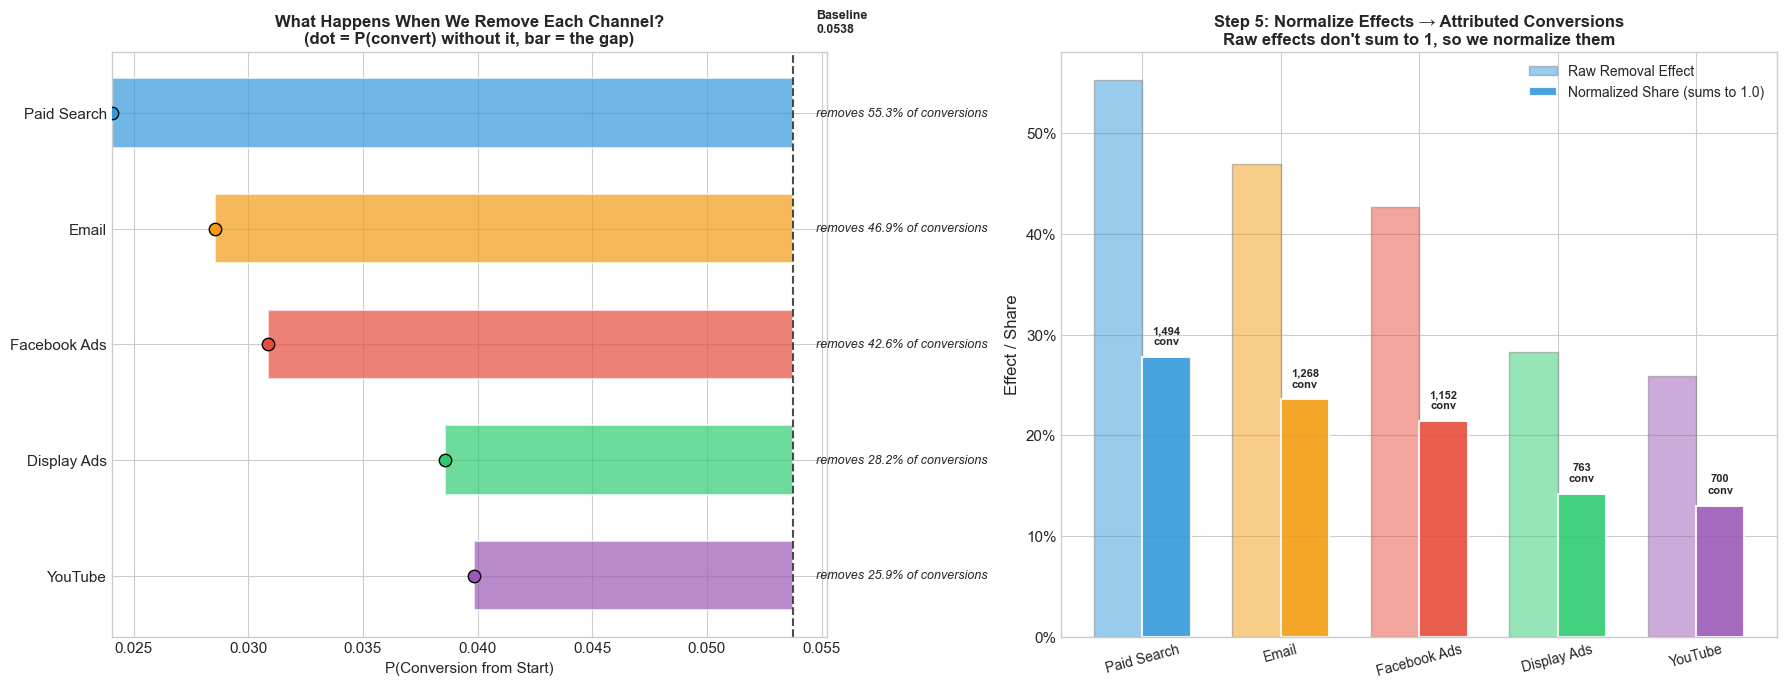


 STEP 5: Normalize Removal Effects → Attributed Conversions

Total observed conversions: 5,376
Sum of all removal effects: 1.9895 (≠ 1.0 — channels overlap!)

Formula: Attributed Conversions = (removal_effect / sum_of_effects) × total_conversions

Channel           Removal Eff    ÷ Sum   = Share   × Total   = Attributed
────────────────────────────────────────────────────────────────────────
  Paid Search         0.5528   ÷ 1.990  =  27.8%   × 5,376  =    1,493.7
  Email               0.4692   ÷ 1.990  =  23.6%   × 5,376  =    1,267.7
  Facebook Ads        0.4262   ÷ 1.990  =  21.4%   × 5,376  =    1,151.8
  Display Ads         0.2822   ÷ 1.990  =  14.2%   × 5,376  =      762.5
  YouTube             0.2591   ÷ 1.990  =  13.0%   × 5,376  =      700.2

  TOTAL               1.9895                100.0%              =    5,376.0

✅ Attributed conversions sum to exactly 5,376 = total observed conversions. ✓


In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 4b: VISUALIZE the removal effect — before vs after for each channel
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- LEFT: Waterfall chart showing conversion probability drop per channel ---
ax1 = axes[0]
removal_df_sorted = removal_df.sort_values('removal_effect', ascending=True)
y_positions = range(len(removal_df_sorted))
channel_colors = {
    'Paid Search': '#3498db', 'Facebook Ads': '#e74c3c', 
    'Display Ads': '#2ecc71', 'Email': '#f39c12', 'YouTube': '#9b59b6'
}

for i, (_, row) in enumerate(removal_df_sorted.iterrows()):
    ch = row['channel']
    color = channel_colors.get(ch, 'gray')
    
    # Bar from p_without to p_with_all (the gap = what removing this channel costs)
    ax1.barh(i, row['p_with_all'] - row['p_without'], left=row['p_without'],
             color=color, alpha=0.7, height=0.6, edgecolor='white', linewidth=1.5)
    
    # Dot at p_without
    ax1.scatter(row['p_without'], i, color=color, s=80, zorder=5, edgecolors='black')
    
    # Label
    ax1.text(row['p_with_all'] + 0.001, i, 
             f"removes {row['removal_effect']:.1%} of conversions",
             va='center', fontsize=9, style='italic')

ax1.axvline(x=baseline_prob, color='black', linestyle='--', alpha=0.7, linewidth=1.5)
ax1.text(baseline_prob + 0.001, len(removal_df_sorted) - 0.3, 
         f'Baseline\n{baseline_prob:.4f}', fontsize=9, fontweight='bold')

ax1.set_yticks(list(y_positions))
ax1.set_yticklabels(removal_df_sorted['channel'], fontsize=11)
ax1.set_xlabel('P(Conversion from Start)', fontsize=11)
ax1.set_title('What Happens When We Remove Each Channel?\n'
              '(dot = P(convert) without it, bar = the gap)', fontweight='bold', fontsize=12)

# --- RIGHT: From removal effects → attributed conversions (the normalization step) ---
ax2 = axes[1]

total_effect = removal_df['removal_effect'].sum()
removal_df_sorted2 = removal_df.sort_values('removal_effect', ascending=False)

# Stacked: raw removal effect (unnormalized) vs normalized share
x = np.arange(len(removal_df_sorted2))
width = 0.35

raw_effects = removal_df_sorted2['removal_effect'].values
normalized_shares = raw_effects / total_effect

bars1 = ax2.bar(x - width/2, raw_effects, width, label='Raw Removal Effect',
                color=[channel_colors[ch] for ch in removal_df_sorted2['channel']], 
                alpha=0.5, edgecolor='gray')
bars2 = ax2.bar(x + width/2, normalized_shares, width, label='Normalized Share (sums to 1.0)',
                color=[channel_colors[ch] for ch in removal_df_sorted2['channel']], 
                alpha=0.9, edgecolor='white', linewidth=1.5)

# Labels on normalized bars showing attributed conversions
total_conv = journeys_df['converted'].sum()
for bar, share, ch in zip(bars2, normalized_shares, removal_df_sorted2['channel']):
    attr_conv = share * total_conv
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{attr_conv:,.0f}\nconv',
             ha='center', va='bottom', fontsize=8, fontweight='bold')

ax2.set_xticks(x)
ax2.set_xticklabels(removal_df_sorted2['channel'], fontsize=10, rotation=15)
ax2.set_ylabel('Effect / Share')
ax2.set_title('Step 5: Normalize Effects → Attributed Conversions\n'
              'Raw effects don\'t sum to 1, so we normalize them', 
              fontweight='bold', fontsize=12)
ax2.legend(fontsize=10)
ax2.yaxis.set_major_formatter(PercentFormatter(1.0))

plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# STEP 5: Final normalization math (print it explicitly)
# ─────────────────────────────────────────────────────────────────────────────

print("\n" + "=" * 70)
print(" STEP 5: Normalize Removal Effects → Attributed Conversions")
print("=" * 70)
print(f"\nTotal observed conversions: {total_conv:,}")
print(f"Sum of all removal effects: {total_effect:.4f} (≠ 1.0 — channels overlap!)")
print(f"\nFormula: Attributed Conversions = (removal_effect / sum_of_effects) × total_conversions\n")

print(f"{'Channel':<15s} {'Removal Eff':>13s} {'÷ Sum':>8s} {'= Share':>9s} {'× Total':>9s} {'= Attributed':>14s}")
print("─" * 72)
for _, row in removal_df.sort_values('removal_effect', ascending=False).iterrows():
    share = row['removal_effect'] / total_effect
    attributed = share * total_conv
    print(f"  {row['channel']:<15s} {row['removal_effect']:>10.4f}   ÷ {total_effect:.3f}  "
          f"= {share:>6.1%}   × {total_conv:>5,}  = {attributed:>10,.1f}")

total_attributed = sum(markov.get_attribution(total_conv).values())
print(f"\n  {'TOTAL':<15s} {total_effect:>10.4f}   {'':>10s}  {'100.0%':>7s}   {'':>9s}  = {total_attributed:>10,.1f}")
print(f"\n✅ Attributed conversions sum to exactly {total_attributed:,.0f} = total observed conversions. ✓")

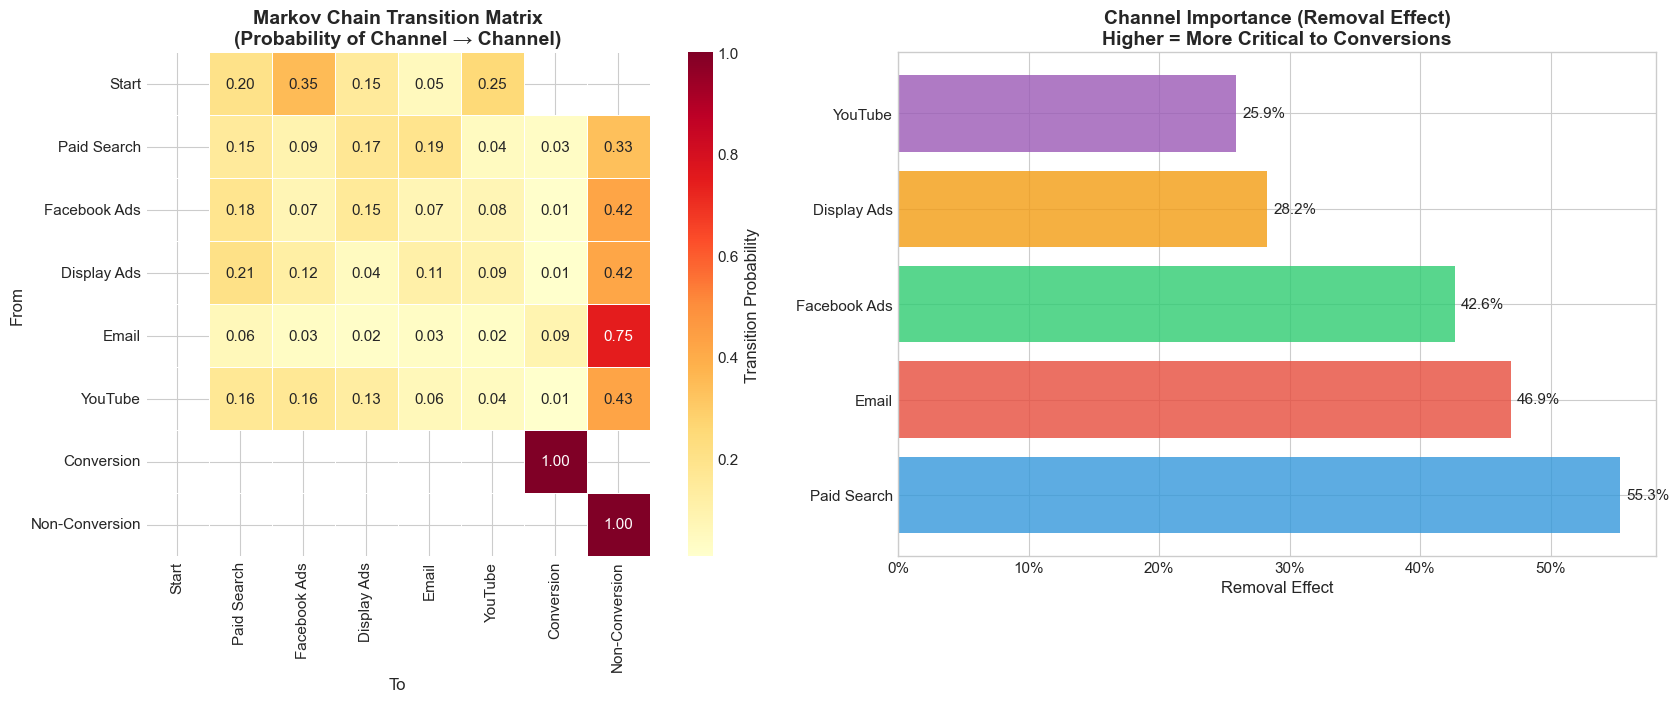


INTERPRETATION:
The removal effect shows each channel's STRUCTURAL importance.
A high removal effect means the channel is critical to the
journey network — removing it would severely disrupt conversion paths.

This is fundamentally different from rule-based models because it
considers how channels ENABLE each other, not just their position.


In [15]:
# ============================================================================
# VISUALIZE: Markov Chain Transition Matrix
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Plot 1: Transition Matrix Heatmap ---
ax1 = axes[0]
# Filter to marketing channels + Start → Conversion/Non-Conversion
display_states = ['Start'] + channels + ['Conversion', 'Non-Conversion']
display_states = [s for s in display_states if s in markov.transition_matrix.index]

trans_display = markov.transition_matrix.loc[display_states, display_states]
mask = trans_display < 0.001  # Hide near-zero values for readability

sns.heatmap(trans_display, annot=True, fmt='.2f', cmap='YlOrRd', 
            ax=ax1, mask=mask, linewidths=0.5, square=True,
            cbar_kws={'label': 'Transition Probability'})
ax1.set_title('Markov Chain Transition Matrix\n(Probability of Channel → Channel)', fontweight='bold')
ax1.set_xlabel('To')
ax1.set_ylabel('From')

# --- Plot 2: Removal Effects Bar Chart ---
ax2 = axes[1]
effects_sorted = sorted(markov.removal_effects.items(), key=lambda x: -x[1])
channels_sorted = [c for c, _ in effects_sorted]
effects_values = [e for _, e in effects_sorted]

bars = ax2.barh(channels_sorted, effects_values, color=colors[:len(channels_sorted)], alpha=0.8)
ax2.set_xlabel('Removal Effect')
ax2.set_title('Channel Importance (Removal Effect)\nHigher = More Critical to Conversions', fontweight='bold')
ax2.xaxis.set_major_formatter(PercentFormatter(1.0))

for bar, val in zip(bars, effects_values):
    ax2.text(val + 0.005, bar.get_y() + bar.get_height()/2.,
             f'{val:.1%}', va='center', fontsize=11)

plt.tight_layout()
plt.show()

print("\nINTERPRETATION:")
print("=" * 60)
print("The removal effect shows each channel's STRUCTURAL importance.")
print("A high removal effect means the channel is critical to the")
print("journey network — removing it would severely disrupt conversion paths.")
print("\nThis is fundamentally different from rule-based models because it")
print("considers how channels ENABLE each other, not just their position.")

---

# Section 6: Shapley Value Attribution

## 6.1 Game Theory Meets Marketing

**Shapley values** come from cooperative game theory (Lloyd Shapley, 1953 — Nobel Prize 2012). The idea: when a group of "players" (marketing channels) cooperate to produce an outcome (conversions), how should we fairly divide the credit?

## 6.2 The Math

The Shapley value for player $i$ in a cooperative game with value function $v$ is:

$$\phi_i(v) = \sum_{S \subseteq N \setminus \{i\}} \frac{|S|! \cdot (|N|-|S|-1)!}{|N|!} \left[ v(S \cup \{i\}) - v(S) \right]$$

Where:
- $N$ = set of all players (channels)
- $S$ = a subset (coalition) of channels not including $i$
- $v(S)$ = the value (conversions) produced by coalition $S$
- $v(S \cup \{i\}) - v(S)$ = the **marginal contribution** of player $i$ to coalition $S$

### In Plain English:
For every possible ordering of channels, look at what adding channel $i$ contributes. Average this across all possible orderings.

## 6.3 Properties of Shapley Values (Why They're "Fair")

1. **Efficiency**: Credits sum to total conversions (no credit is wasted)
2. **Symmetry**: Equal contributors get equal credit
3. **Null Player**: A channel with zero marginal contribution gets zero credit
4. **Linearity/Additivity**: Credits are additive across games

## 6.4 Computational Challenge

For $n$ channels, we need to evaluate $2^n$ coalitions. This is tractable for 5-10 channels but becomes infeasible for 20+ channels. In practice, we use **sampling-based approximations**.

In [18]:
# ============================================================================
# SHAPLEY VALUE ATTRIBUTION — Full Implementation
# ============================================================================

class ShapleyAttribution:
    """
    Implements Shapley value attribution for marketing channels.
    
    The value function v(S) = number of conversions where the converting 
    journey ONLY involved channels in set S.
    """
    
    def __init__(self):
        self.shapley_values = None
        self.coalition_values = None

    def _factorial(self, k):
        """Simple factorial to avoid np.math dependency."""
        result = 1
        for i in range(2, k + 1):
            result *= i
        return result
    
    def _compute_coalition_value(self, journeys_df, coalition):
        """
        Compute v(S): the number of conversions from journeys that only
        use channels in the coalition S.
        
        A converting journey is 'attributed' to coalition S if ALL channels
        in that journey are members of S.
        """
        coalition_set = set(coalition)
        count = 0
        
        for _, row in journeys_df[journeys_df['converted']].iterrows():
            path_channels = set(row['journey_path'].split(' > '))
            if path_channels.issubset(coalition_set):
                count += 1
        
        return count
    
    def fit(self, journeys_df, channels):
        """
        Calculate Shapley values for each channel.
        
        For tractability with our 5 channels, we compute exact Shapley values
        (2^5 = 32 coalitions — very manageable).
        """
        n = len(channels)
        self.channels = channels
        
        # Pre-compute all coalition values
        print("Computing coalition values (2^n = {} coalitions)...".format(2**n))
        self.coalition_values = {}
        
        for r in range(n + 1):
            for coalition in itertools.combinations(channels, r):
                key = frozenset(coalition)
                self.coalition_values[key] = self._compute_coalition_value(
                    journeys_df, coalition
                )
        
        # Calculate Shapley values
        print("Computing Shapley values...")
        self.shapley_values = {}
        
        for channel in channels:
            shapley_val = 0
            other_channels = [c for c in channels if c != channel]
            
            for r in range(len(other_channels) + 1):
                for S in itertools.combinations(other_channels, r):
                    S_set = set(S)
                    S_key = frozenset(S_set)
                    S_with_channel_key = frozenset(S_set | {channel})
                    
                    marginal = (
                        self.coalition_values[S_with_channel_key]
                        - self.coalition_values[S_key]
                    )
                    
                    # Shapley weight
                    weight = (
                        self._factorial(len(S_set)) * 
                        self._factorial(n - len(S_set) - 1) / 
                        self._factorial(n)
                    )
                    
                    shapley_val += weight * marginal
            
            self.shapley_values[channel] = shapley_val
        
        return self
    
    def get_attribution(self):
        """Return Shapley values as attributed conversions."""
        return self.shapley_values.copy()


# Fit Shapley attribution
print("=" * 70)
print(" SHAPLEY VALUE ATTRIBUTION")
print("=" * 70)

shapley = ShapleyAttribution()
shapley.fit(journeys_df, channels)

total_conv = journeys_df['converted'].sum()

print("\n" + "=" * 70)
print(" SHAPLEY VALUES — ATTRIBUTED CONVERSIONS")
print("=" * 70)
print(f"\nTotal actual conversions: {total_conv:,}")
shapley_total = sum(shapley.shapley_values.values())
print(f"Sum of Shapley values: {shapley_total:,.1f}")
print(f"Efficiency check: {shapley_total/total_conv:.4f} (should be ~1.0)\n")

for channel, val in sorted(shapley.shapley_values.items(), key=lambda x: -x[1]):
    pct = val / total_conv * 100
    bar = '█' * max(1, int(pct * 2))
    print(f"  {channel:<15s}: {val:>8,.1f} conversions ({pct:>5.1f}%) {bar}")

print("\nNOTE: Shapley values may not sum exactly to total conversions")
print("because the coalition value function counts journeys where ALL")
print("channels are in the coalition. Multi-channel journeys get split.")

 SHAPLEY VALUE ATTRIBUTION
Computing coalition values (2^n = 32 coalitions)...
Computing Shapley values...

 SHAPLEY VALUES — ATTRIBUTED CONVERSIONS

Total actual conversions: 5,376
Sum of Shapley values: 5,376.0
Efficiency check: 1.0000 (should be ~1.0)

  Paid Search    :  1,610.2 conversions ( 30.0%) ███████████████████████████████████████████████████████████
  Email          :  1,294.7 conversions ( 24.1%) ████████████████████████████████████████████████
  Facebook Ads   :  1,201.0 conversions ( 22.3%) ████████████████████████████████████████████
  YouTube        :    653.4 conversions ( 12.2%) ████████████████████████
  Display Ads    :    616.8 conversions ( 11.5%) ██████████████████████

NOTE: Shapley values may not sum exactly to total conversions
because the coalition value function counts journeys where ALL
channels are in the coalition. Multi-channel journeys get split.


---

# Section 7: Data-Driven Attribution with Machine Learning

## 7.1 The ML Approach to Attribution

Instead of using handcrafted rules or game theory, we can train a machine learning model to predict conversion probability based on journey features, then use the model to understand each channel's contribution.

### Approaches:
1. **Logistic Regression**: Interpretable, feature importance = attribution
2. **Gradient Boosted Trees**: More accurate, use SHAP for attribution
3. **Deep Learning (LSTM/Transformer)**: Sequence-aware, but less interpretable

### The Key Idea:
Build features that describe each user's journey (which channels they touched, how many times, in what order, how recently), then predict conversion. Channel importance in the model ≈ channel attribution.

## 7.2 Key Benefits

Platform attribution (Google, Meta) uses their own black-box models that are biased toward giving themselves credit. Building your own ML attribution model lets you:
1. **Control the methodology** — no platform bias
2. **Include cross-channel interactions** — see how channels work together
3. **Quantify uncertainty** — confidence intervals on attribution
4. **Customize to your business** — weight recent vs. historical touchpoints

In [20]:
# ============================================================================
# FEATURE ENGINEERING FOR ML-BASED ATTRIBUTION
# ============================================================================

def build_journey_features(touchpoints_df, journeys_df, channels):
    """
    Build a feature matrix for ML-based attribution.
    
    Features per user:
    - Binary: Did the user touch channel X? (presence)
    - Count: How many times did they touch channel X?
    - Recency: Days since last touch on channel X (before conversion/end)
    - First/Last indicators
    - Journey-level: total touchpoints, unique channels, journey duration
    """
    features = []
    
    for _, journey in journeys_df.iterrows():
        user_id = journey['user_id']
        user_touches = touchpoints_df[touchpoints_df['user_id'] == user_id]
        
        row = {'user_id': user_id, 'converted': journey['converted']}
        
        # Channel-level features
        for channel in channels:
            ch_touches = user_touches[user_touches['channel'] == channel]
            
            # Presence (binary)
            row[f'{channel}_present'] = 1 if len(ch_touches) > 0 else 0
            
            # Count
            row[f'{channel}_count'] = len(ch_touches)
            
            # Total cost on this channel
            row[f'{channel}_cost'] = ch_touches['cost'].sum()
            
            # Is first touch?
            row[f'{channel}_is_first'] = 1 if (len(ch_touches) > 0 and 
                                                ch_touches.iloc[0]['is_first_touch']) else 0
            
            # Is last touch?
            row[f'{channel}_is_last'] = 1 if (len(ch_touches) > 0 and 
                                               ch_touches.iloc[-1]['is_last_touch']) else 0
        
        # Journey-level features
        row['total_touchpoints'] = journey['journey_length']
        row['unique_channels'] = journey['unique_channels']
        row['journey_duration_days'] = journey['journey_duration_days']
        
        features.append(row)
    
    return pd.DataFrame(features)


# Build features (this may take a moment with 100K users)
print("Building journey features for ML model...")
print("(Processing 100,000 user journeys...)\n")

sample=False
if sample:
    # For efficiency, let's use a sample for the ML model
    sample_size = 30000  # Use 30K users for faster computation
    sample_idx = np.random.choice(len(journeys_df), size=sample_size, replace=False)
    journeys_sample = journeys_df.iloc[sample_idx].reset_index(drop=True)
    sample_user_ids = set(journeys_sample['user_id'])
    touchpoints_sample = touchpoints_df[touchpoints_df['user_id'].isin(sample_user_ids)].reset_index(drop=True)

    features_df = build_journey_features(touchpoints_sample, journeys_sample, channels)
else:
    features_df = build_journey_features(touchpoints_df, journeys_df, channels)


print(f"Feature matrix shape: {features_df.shape}")
print(f"Conversion rate in sample: {features_df['converted'].mean():.1%}")
print(f"\nFeatures created:")
for col in features_df.columns:
    if col not in ['user_id', 'converted']:
        print(f"  • {col}")

Building journey features for ML model...
(Processing 100,000 user journeys...)

Feature matrix shape: (100000, 30)
Conversion rate in sample: 5.4%

Features created:
  • Paid Search_present
  • Paid Search_count
  • Paid Search_cost
  • Paid Search_is_first
  • Paid Search_is_last
  • Facebook Ads_present
  • Facebook Ads_count
  • Facebook Ads_cost
  • Facebook Ads_is_first
  • Facebook Ads_is_last
  • Display Ads_present
  • Display Ads_count
  • Display Ads_cost
  • Display Ads_is_first
  • Display Ads_is_last
  • Email_present
  • Email_count
  • Email_cost
  • Email_is_first
  • Email_is_last
  • YouTube_present
  • YouTube_count
  • YouTube_cost
  • YouTube_is_first
  • YouTube_is_last
  • total_touchpoints
  • unique_channels
  • journey_duration_days


In [21]:
# ============================================================================
# LOGISTIC REGRESSION ATTRIBUTION
# ============================================================================

# Prepare data
feature_cols = [col for col in features_df.columns if col not in ['user_id', 'converted']]
X = features_df[feature_cols].values
y = features_df['converted'].astype(int).values

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/test split (stratified to maintain conversion rate)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)

# Fit Logistic Regression
print("=" * 70)
print(" LOGISTIC REGRESSION ATTRIBUTION MODEL")
print("=" * 70)

lr_model = LogisticRegression(
    max_iter=1000, 
    class_weight='balanced',  # Handle class imbalance
    C=1.0,                    # Regularization
    random_state=42
)
lr_model.fit(X_train, y_train)

# Model performance
y_pred_prob = lr_model.predict_proba(X_test)[:, 1]
auc_score = roc_auc_score(y_test, y_pred_prob)
avg_precision = average_precision_score(y_test, y_pred_prob)

print(f"\nModel Performance:")
print(f"  ROC AUC: {auc_score:.4f}")
print(f"  Average Precision: {avg_precision:.4f}")
print(f"  Baseline (random): {y_test.mean():.4f}")

# Feature importance (coefficients)
print("\n" + "=" * 70)
print(" FEATURE IMPORTANCE (Logistic Regression Coefficients)")
print("=" * 70)

coef_df = pd.DataFrame({
    'feature': feature_cols,
    'coefficient': lr_model.coef_[0],
    'abs_coefficient': np.abs(lr_model.coef_[0]),
    'odds_ratio': np.exp(lr_model.coef_[0])
}).sort_values('abs_coefficient', ascending=False)

print("\nTop features by absolute coefficient magnitude:\n")
for _, row in coef_df.head(15).iterrows():
    direction = '+' if row['coefficient'] > 0 else '-'
    print(f"  {direction} {row['feature']:<30s}  coef={row['coefficient']:>7.3f}  "
          f"odds_ratio={row['odds_ratio']:>6.3f}")

print("""
\nINTERPRETATION:
• Positive coefficient → increases conversion probability
• Odds ratio > 1 → that feature makes conversion more likely
• Odds ratio < 1 → that feature makes conversion less likely
• Example: odds_ratio=2.0 means 2x more likely to convert
""")

# ============================================================================
# EXTRACT CHANNEL-LEVEL ATTRIBUTION FROM LOGISTIC REGRESSION
# ============================================================================

# Sum up coefficients by channel (presence + count + cost + position features)
channel_importance = {}
for channel in channels:
    ch_features = [col for col in feature_cols if channel.replace(' ', '_') in col.replace(' ', '_') 
                   or channel in col]
    ch_coefs = coef_df[coef_df['feature'].isin(ch_features)]['coefficient'].sum()
    channel_importance[channel] = abs(ch_coefs)

# Normalize to get attribution shares
total_imp = sum(channel_importance.values())
lr_attribution = {ch: (imp / total_imp) * total_conv for ch, imp in channel_importance.items()}

print("\n" + "=" * 70)
print(" ML-BASED ATTRIBUTION (Logistic Regression)")
print("=" * 70)
for channel, conv in sorted(lr_attribution.items(), key=lambda x: -x[1]):
    pct = conv / total_conv * 100
    print(f"  {channel:<15s}: {conv:>8,.1f} conversions ({pct:>5.1f}%)")

 LOGISTIC REGRESSION ATTRIBUTION MODEL

Model Performance:
  ROC AUC: 0.7014
  Average Precision: 0.0991
  Baseline (random): 0.0537

 FEATURE IMPORTANCE (Logistic Regression Coefficients)

Top features by absolute coefficient magnitude:

  + Email_is_last                   coef=  0.403  odds_ratio= 1.496
  - Display Ads_is_last             coef= -0.321  odds_ratio= 0.726
  - YouTube_is_last                 coef= -0.311  odds_ratio= 0.733
  + Paid Search_is_last             coef=  0.290  odds_ratio= 1.336
  - Facebook Ads_is_last            coef= -0.113  odds_ratio= 0.893
  - Display Ads_count               coef= -0.083  odds_ratio= 0.920
  - Facebook Ads_present            coef= -0.071  odds_ratio= 0.931
  + Facebook Ads_count              coef=  0.062  odds_ratio= 1.064
  + Email_present                   coef=  0.055  odds_ratio= 1.057
  + Display Ads_present             coef=  0.048  odds_ratio= 1.049
  - Email_count                     coef= -0.045  odds_ratio= 0.956
  + Paid Sear

 GRADIENT BOOSTED TREES ATTRIBUTION

GBM ROC AUC: 0.6966 (vs LR: 0.7014)


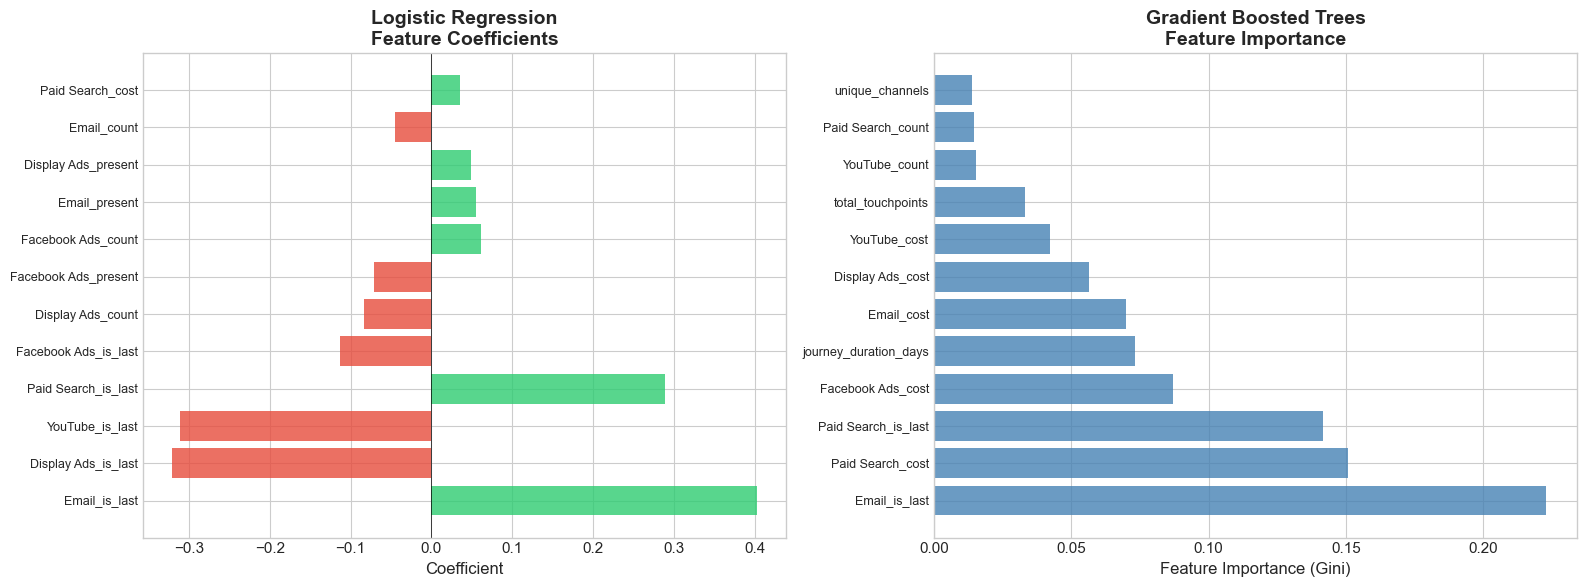


 GBM-BASED ATTRIBUTION
  Paid Search    :  1,921.0 conversions ( 35.7%)
  Email          :  1,906.3 conversions ( 35.5%)
  Facebook Ads   :    679.7 conversions ( 12.6%)
  Display Ads    :    459.0 conversions (  8.5%)
  YouTube        :    410.0 conversions (  7.6%)


In [22]:
# ============================================================================
# GRADIENT BOOSTED TREES + FEATURE IMPORTANCE
# ============================================================================

print("=" * 70)
print(" GRADIENT BOOSTED TREES ATTRIBUTION")
print("=" * 70)

# Fit GBM
gbm = GradientBoostingClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    random_state=42
)
gbm.fit(X_train, y_train)

# Performance
y_pred_gbm = gbm.predict_proba(X_test)[:, 1]
auc_gbm = roc_auc_score(y_test, y_pred_gbm)
print(f"\nGBM ROC AUC: {auc_gbm:.4f} (vs LR: {auc_score:.4f})")

# Feature importance (Gini importance)
gbm_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': gbm.feature_importances_
}).sort_values('importance', ascending=False)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# LR coefficients
ax1 = axes[0]
top_lr = coef_df.head(12)
colors_lr = ['#2ecc71' if c > 0 else '#e74c3c' for c in top_lr['coefficient']]
ax1.barh(range(len(top_lr)), top_lr['coefficient'], color=colors_lr, alpha=0.8)
ax1.set_yticks(range(len(top_lr)))
ax1.set_yticklabels(top_lr['feature'], fontsize=9)
ax1.set_xlabel('Coefficient')
ax1.set_title('Logistic Regression\nFeature Coefficients', fontweight='bold')
ax1.axvline(x=0, color='black', linewidth=0.5)

# GBM importance
ax2 = axes[1]
top_gbm = gbm_importance.head(12)
ax2.barh(range(len(top_gbm)), top_gbm['importance'], color='steelblue', alpha=0.8)
ax2.set_yticks(range(len(top_gbm)))
ax2.set_yticklabels(top_gbm['feature'], fontsize=9)
ax2.set_xlabel('Feature Importance (Gini)')
ax2.set_title('Gradient Boosted Trees\nFeature Importance', fontweight='bold')

plt.tight_layout()
plt.show()

# Aggregate GBM importance by channel
gbm_channel_imp = {}
for channel in channels:
    ch_features = [col for col in feature_cols if channel.replace(' ', '_') in col.replace(' ', '_')
                   or channel in col]
    ch_imp = gbm_importance[gbm_importance['feature'].isin(ch_features)]['importance'].sum()
    gbm_channel_imp[channel] = ch_imp

total_gbm_imp = sum(gbm_channel_imp.values())
gbm_attribution = {ch: (imp / total_gbm_imp) * total_conv for ch, imp in gbm_channel_imp.items()}

print("\n" + "=" * 70)
print(" GBM-BASED ATTRIBUTION")
print("=" * 70)
for channel, conv in sorted(gbm_attribution.items(), key=lambda x: -x[1]):
    pct = conv / total_conv * 100
    print(f"  {channel:<15s}: {conv:>8,.1f} conversions ({pct:>5.1f}%)")

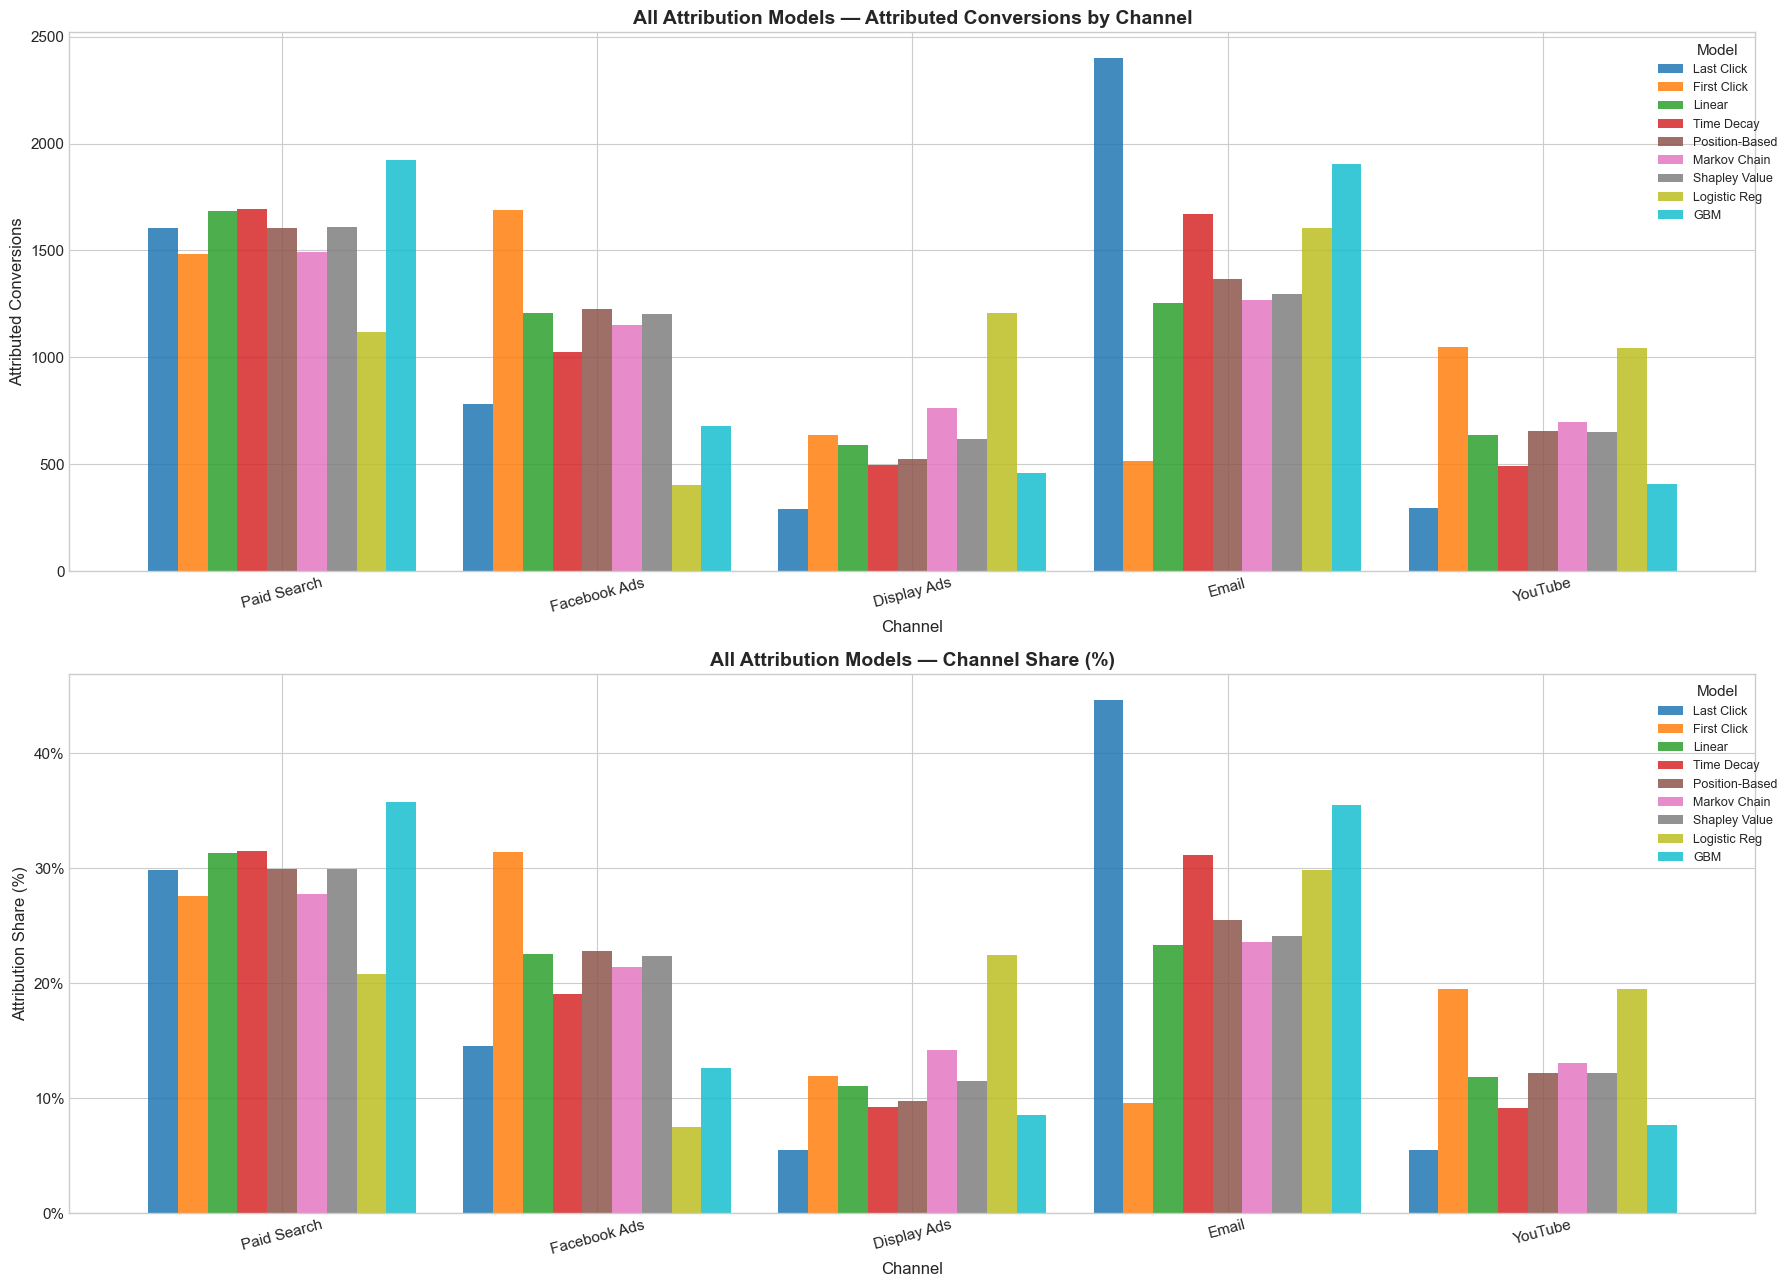

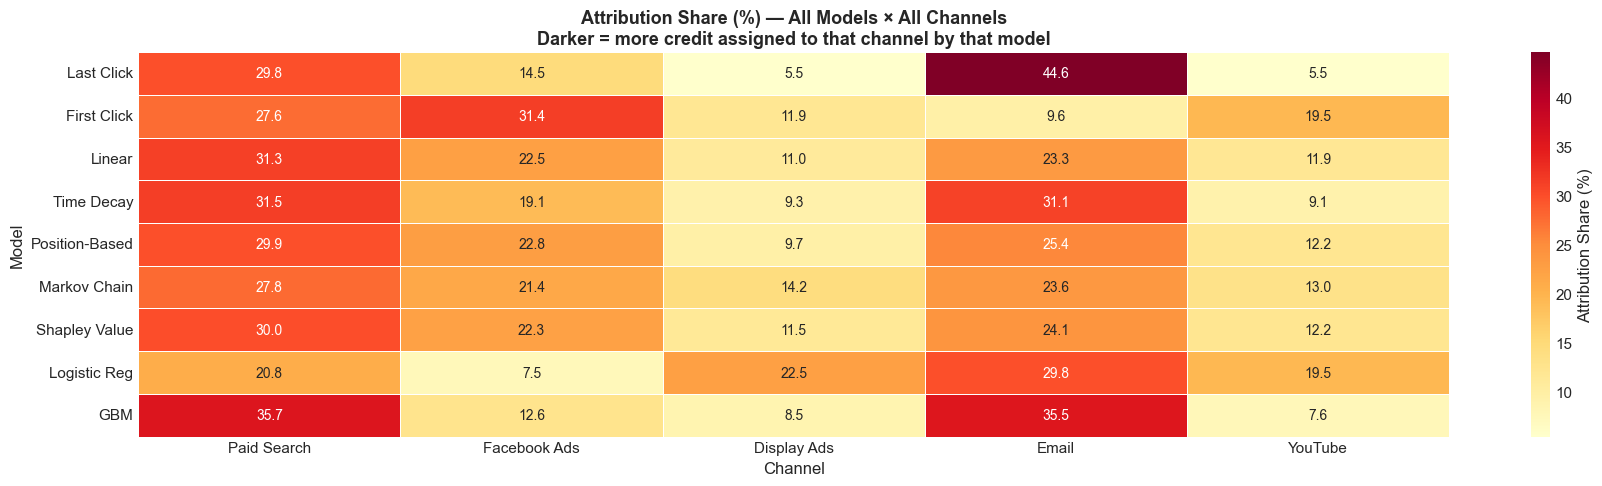

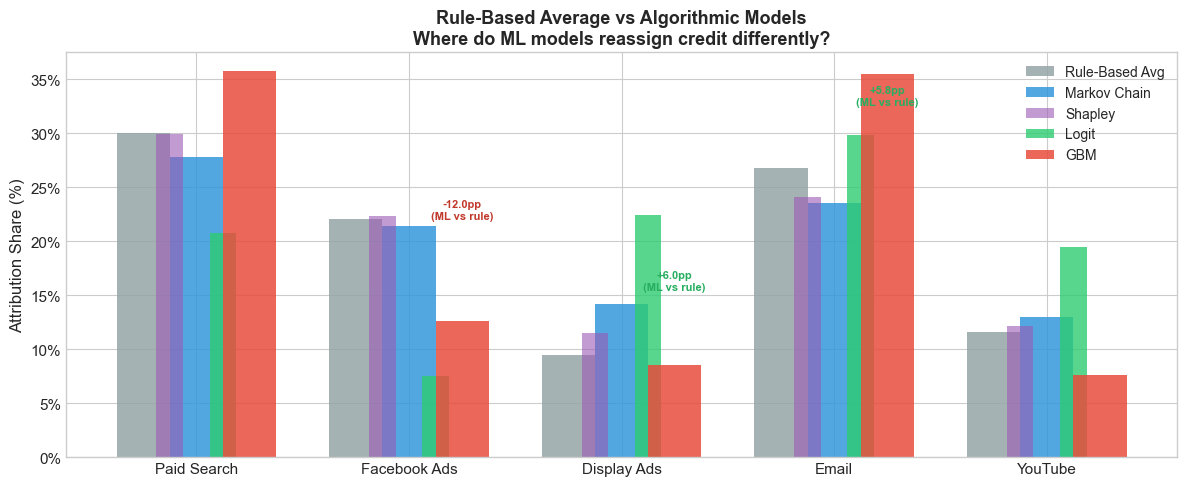


 MODEL COMPARISON TABLE (Attribution Shares %)
              Last Click  First Click  Linear  Time Decay  Position-Based  Markov Chain  Shapley Value  Logistic Reg   GBM
Paid Search         29.8         27.6    31.3        31.5            29.9          27.8           30.0          20.8  35.7
Facebook Ads        14.5         31.4    22.5        19.1            22.8          21.4           22.3           7.5  12.6
Display Ads          5.5         11.9    11.0         9.3             9.7          14.2           11.5          22.5   8.5
Email               44.6          9.6    23.3        31.1            25.4          23.6           24.1          29.8  35.5
YouTube              5.5         19.5    11.9         9.1            12.2          13.0           12.2          19.5   7.6

 DISAGREEMENT: Range Across ALL 9 Models (Max% - Min%)
  Email          :  35.0 pp  ███████████████████████████████████
  Facebook Ads   :  24.0 pp  ███████████████████████
  Display Ads    :  17.0 pp  ███████████

In [25]:
# ============================================================================
# MEGA COMPARISON: All Attribution Models Side-by-Side
# (Including ML-based: Logistic Regression & Gradient Boosted Trees)
# ============================================================================

# Compile all results into one DataFrame
comparison = pd.DataFrame({
    'Last Click':      {ch: results['last_click'].get(ch, 0)     for ch in channels},
    'First Click':     {ch: results['first_click'].get(ch, 0)    for ch in channels},
    'Linear':          {ch: results['linear'].get(ch, 0)         for ch in channels},
    'Time Decay':      {ch: results['time_decay'].get(ch, 0)     for ch in channels},
    'Position-Based':  {ch: results['position_based'].get(ch, 0) for ch in channels},
    'Markov Chain':    {ch: markov_attribution.get(ch, 0)        for ch in channels},
    'Shapley Value':   {ch: shapley.shapley_values.get(ch, 0)    for ch in channels},
    'Logistic Reg':    {ch: lr_attribution.get(ch, 0)            for ch in channels},
    'GBM':             {ch: gbm_attribution.get(ch, 0)           for ch in channels},
})

# Normalize to shares (%)
comparison_shares = comparison.div(comparison.sum()) * 100

# Colour palette — one colour per model
n_models = len(comparison.columns)
model_colors = plt.cm.tab10(np.linspace(0, 1, n_models))

# ─────────────────────────────────────────────────────────────────────────────
# Plot 1 & 2: Attributed Conversions + Shares
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(18, 13))

comparison.plot(kind='bar', ax=axes[0], width=0.85, alpha=0.85, color=model_colors)
axes[0].set_xlabel('Channel')
axes[0].set_ylabel('Attributed Conversions')
axes[0].set_title('All Attribution Models — Attributed Conversions by Channel',
                  fontsize=14, fontweight='bold')
axes[0].legend(title='Model', bbox_to_anchor=(1.02, 1), fontsize=9)
axes[0].tick_params(axis='x', rotation=15)

comparison_shares.plot(kind='bar', ax=axes[1], width=0.85, alpha=0.85, color=model_colors)
axes[1].set_xlabel('Channel')
axes[1].set_ylabel('Attribution Share (%)')
axes[1].set_title('All Attribution Models — Channel Share (%)',
                  fontsize=14, fontweight='bold')
axes[1].legend(title='Model', bbox_to_anchor=(1.02, 1), fontsize=9)
axes[1].tick_params(axis='x', rotation=15)
axes[1].yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.0f}%'))

plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# Plot 3: Heatmap — channel × model, shows share (%)
# ─────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(18, 5))
sns.heatmap(comparison_shares.T, annot=True, fmt='.1f', cmap='YlOrRd',
            ax=ax, linewidths=0.5, cbar_kws={'label': 'Attribution Share (%)'},
            annot_kws={'size': 10})
ax.set_title('Attribution Share (%) — All Models × All Channels\n'
             'Darker = more credit assigned to that channel by that model',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Channel')
ax.set_ylabel('Model')
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# Plot 4: Rule-based avg vs algorithmic models
# ─────────────────────────────────────────────────────────────────────────────
rule_based_cols = ['Last Click', 'First Click', 'Linear', 'Time Decay', 'Position-Based']
rule_based_avg  = comparison_shares[rule_based_cols].mean(axis=1)

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(channels))
width = 0.25

ax.bar(x - width,      rule_based_avg.values,                      width,     label='Rule-Based Avg', color='#95a5a6', alpha=0.85)
ax.bar(x,              comparison_shares['Markov Chain'].values,    width,     label='Markov Chain',   color='#3498db', alpha=0.85)
ax.bar(x - width*0.5,  comparison_shares['Shapley Value'].values,  width*0.5, label='Shapley',        color='#9b59b6', alpha=0.6)
ax.bar(x + width*0.5,  comparison_shares['Logistic Reg'].values,   width*0.5, label='Logit',          color='#2ecc71', alpha=0.8)
ax.bar(x + width,      comparison_shares['GBM'].values,            width,     label='GBM',            color='#e74c3c', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(channels, fontsize=11)
ax.set_ylabel('Attribution Share (%)')
ax.set_title('Rule-Based Average vs Algorithmic Models\n'
             'Where do ML models reassign credit differently?',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.0f}%'))

# Annotate the biggest ML-vs-rule-based gaps
for i, ch in enumerate(channels):
    ml_avg   = (comparison_shares.loc[ch, 'Logistic Reg'] + comparison_shares.loc[ch, 'GBM']) / 2
    rule_avg = rule_based_avg[ch]
    gap      = ml_avg - rule_avg
    if abs(gap) > 3:
        ax.annotate(f'{gap:+.1f}pp\n(ML vs rule)',
                    xy=(i + width, max(ml_avg, rule_avg)),
                    ha='center', fontsize=8,
                    color='#c0392b' if gap < 0 else '#27ae60',
                    fontweight='bold')

plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# Summary table + disagreement
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 120)
print(" MODEL COMPARISON TABLE (Attribution Shares %)")
print("=" * 120)
print(comparison_shares.round(1).to_string())

print("\n" + "=" * 80)
print(" DISAGREEMENT: Range Across ALL 9 Models (Max% - Min%)")
print("=" * 80)
ranges = comparison_shares.max(axis=1) - comparison_shares.min(axis=1)
for ch in ranges.sort_values(ascending=False).index:
    bar = '█' * int(ranges[ch])
    print(f"  {ch:<15s}: {ranges[ch]:>5.1f} pp  {bar}")

print("""
KEY TAKEAWAY on ML models:
  • If LR/GBM closely match Markov/Shapley → algorithmic models are stable
  • Large gaps between ML and rule-based reveal where path order / frequency
    matter more than simple position rules
  • ML models can be biased by correlated features (e.g. Email is only sent
    to warm users → inflated LR coefficient)
  • Use ML attribution as a SIGNAL, not a standalone source of truth
""")

---

# Section 8: Incrementality — The Gold Standard of Measurement

## 8.1 Why Incrementality Matters More Than Attribution

Attribution answers: *"Who gets credit for this conversion?"*
Incrementality answers: *"Did this ad CAUSE the conversion to happen?"*

These are fundamentally different questions. A user might have:
- Seen your Facebook ad → clicked → purchased
- But would have purchased **anyway** through organic search

In this case, Facebook gets attribution credit, but its **incremental** contribution is **zero**.

### The Economics of Incrementality:
If a channel has high attribution but low incrementality, you're paying for conversions that would have happened for free. This is literally burning money.

## 8.2 Experimental Approaches

### 1. Randomized Controlled Trials (RCTs)
The gold standard. Randomly split users into:
- **Treatment group**: Sees the ad
- **Control group**: Doesn't see the ad (or sees a PSA/ghost ad)
- **Incremental lift** = Treatment conversion rate - Control conversion rate

### 2. Geo-Lift Experiments
Can't randomize at user level? Randomize by geography:
- **Treatment markets**: Run ads normally
- **Holdout markets**: Turn off ads completely
- Use synthetic control to estimate counterfactual

### 3. Ghost Ads / PSA Tests
In programmatic display:
- **Treatment**: User sees your ad
- **Control**: User sees a blank ad (ghost) or public service announcement
- Both groups were eligible to see the ad, so selection bias is minimized

### 4. Conversion Lift Studies
Platform-native experiments (Meta Conversion Lift, Google Brand Lift):
- Platform handles randomization
- Results are biased toward that platform (be cautious)

## 8.3 When Experiments Aren't Possible: Quasi-Experimental Methods

### Propensity Score Matching (PSM)
Match treated users with similar untreated users based on observable characteristics, then compare outcomes.

### Difference-in-Differences (DiD)
Compare the change in outcomes between treatment and control groups before and after an intervention.

### Regression Discontinuity
If treatment is assigned based on a threshold (e.g., users above a certain score see ads), compare outcomes just above and below the threshold.

In [24]:
# ============================================================================
# SIMULATING AN INCREMENTALITY EXPERIMENT
# ============================================================================

def simulate_incrementality_experiment(n_users=50000, seed=42):
    """
    Simulate a conversion lift experiment for Facebook Ads.
    
    Ground truth:
    - Base conversion rate (without Facebook ads): 2%
    - True incremental lift from Facebook ads: 1.5 percentage points
    - So treatment group converts at 3.5%, control at 2%
    - True incrementality rate: 1.5/3.5 = 42.9%
    
    This means ~43% of Facebook-attributed conversions are truly incremental.
    The rest would have happened anyway!
    """
    np.random.seed(seed)
    
    # True parameters
    base_conv_rate = 0.020       # 2% base conversion rate
    true_fb_lift = 0.015         # 1.5 pp incremental lift
    treatment_conv_rate = base_conv_rate + true_fb_lift  # 3.5%
    
    # Random assignment
    treatment = np.random.binomial(1, 0.5, n_users)  # 50/50 split
    
    # Add some confounding: users with higher purchase intent are slightly
    # more likely to be served ads in real life (we control for this in RCT)
    purchase_intent = np.random.beta(2, 8, n_users)  # Skewed low
    
    # Conversion (RCT so no confounding)
    conversion = np.zeros(n_users)
    for i in range(n_users):
        if treatment[i] == 1:
            conversion[i] = np.random.binomial(1, treatment_conv_rate + purchase_intent[i] * 0.01)
        else:
            conversion[i] = np.random.binomial(1, base_conv_rate + purchase_intent[i] * 0.01)
    
    return pd.DataFrame({
        'user_id': range(n_users),
        'treatment': treatment,
        'converted': conversion.astype(int),
        'purchase_intent': purchase_intent
    }), base_conv_rate, true_fb_lift

experiment_df, base_rate, true_lift = simulate_incrementality_experiment()

# Analyze the experiment
treatment_group = experiment_df[experiment_df['treatment'] == 1]
control_group = experiment_df[experiment_df['treatment'] == 0]

treatment_conv_rate = treatment_group['converted'].mean()
control_conv_rate = control_group['converted'].mean()
observed_lift = treatment_conv_rate - control_conv_rate

# Statistical significance test
from scipy.stats import norm

n_treatment = len(treatment_group)
n_control = len(control_group)
pooled_se = np.sqrt(
    treatment_conv_rate * (1 - treatment_conv_rate) / n_treatment +
    control_conv_rate * (1 - control_conv_rate) / n_control
)
z_score = observed_lift / pooled_se
p_value = 2 * (1 - norm.cdf(abs(z_score)))

# Confidence interval
ci_lower = observed_lift - 1.96 * pooled_se
ci_upper = observed_lift + 1.96 * pooled_se

# Incrementality rate
if treatment_conv_rate > 0:
    incrementality_rate = observed_lift / treatment_conv_rate
else:
    incrementality_rate = 0

print("=" * 70)
print(" INCREMENTALITY EXPERIMENT RESULTS")
print(" Channel: Facebook Ads (Simulated RCT)")  
print("=" * 70)

print(f"\n{'Group':<20s} {'N':>10s} {'Conversions':>15s} {'Conv Rate':>12s}")
print("-" * 57)
print(f"{'Treatment (saw ad)':<20s} {n_treatment:>10,d} {treatment_group['converted'].sum():>15,d} {treatment_conv_rate:>11.2%}")
print(f"{'Control (no ad)':<20s} {n_control:>10,d} {control_group['converted'].sum():>15,d} {control_conv_rate:>11.2%}")

print(f"\n{'Metric':<35s} {'Value':>15s}")
print("-" * 50)
print(f"{'Observed Incremental Lift':<35s} {observed_lift:>14.3%}")
print(f"{'95% Confidence Interval':<35s} [{ci_lower:.3%}, {ci_upper:.3%}]")
print(f"{'Z-Score':<35s} {z_score:>15.2f}")
print(f"{'P-Value':<35s} {p_value:>15.6f}")
print(f"{'Statistically Significant?':<35s} {'YES' if p_value < 0.05 else 'NO':>15s}")
print(f"{'Incrementality Rate':<35s} {incrementality_rate:>14.1%}")

print(f"\n{'True Lift (ground truth)':<35s} {true_lift:>14.3%}")
print(f"{'True Incrementality Rate':<35s} {true_lift/(base_rate+true_lift):>14.1%}")

print(f"""
\nINTERPRETATION:
{'='*60}
• Of all conversions attributed to Facebook, only ~{incrementality_rate:.0%} are 
  truly INCREMENTAL (caused by the ad).
• The other ~{1-incrementality_rate:.0%} would have happened WITHOUT the ad.
• This means traditional attribution OVERCREDITS Facebook by 
  ~{1/incrementality_rate:.1f}x for this campaign.

This is why incrementality experiments are essential: they reveal the 
TRUE causal impact, not just the attributed impact.
""")

 INCREMENTALITY EXPERIMENT RESULTS
 Channel: Facebook Ads (Simulated RCT)

Group                         N     Conversions    Conv Rate
---------------------------------------------------------
Treatment (saw ad)       24,947             904       3.62%
Control (no ad)          25,053             531       2.12%

Metric                                        Value
--------------------------------------------------
Observed Incremental Lift                   1.504%
95% Confidence Interval             [1.212%, 1.797%]
Z-Score                                       10.08
P-Value                                    0.000000
Statistically Significant?                      YES
Incrementality Rate                          41.5%

True Lift (ground truth)                    1.500%
True Incrementality Rate                     42.9%


INTERPRETATION:
• Of all conversions attributed to Facebook, only ~42% are 
  truly INCREMENTAL (caused by the ad).
• The other ~58% would have happened WITHOUT the a